# Real Madrid ACWR Pipeline — Data Engineering & Feature Engineering
**Group A | trAIn Labs | 2024–25 Season**


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
df = pd.read_csv("data/data_acute_vs_chronic.csv")

In [123]:
df.head()

,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth
0,37191,period_1683,BP 2351,activity_1389,2024-12-16T00:00:00Z,Central Back,NaN,1003.372036,0,0.000000,184.0,79.0,1997-06-22
1,37191,period_4407,G 1669,activity_2423,2025-01-01T00:00:00Z,Central Back,NaN,1223.749101,4,4.960388,184.0,79.0,1997-06-22
2,37191,period_883,BP 4893,activity_4655,2025-04-06T00:00:00Z,Central Back,NaN,747.250469,4,0.000000,184.0,79.0,1997-06-22
3,37191,period_1790,G 3164,activity_911,2025-04-03T00:00:00Z,Central Back,NaN,1196.351675,2,0.000000,184.0,79.0,1997-06-22
4,37191,period_2421,BP 0518,activity_3073,2025-05-06T00:00:00Z,Central Back,NaN,322.200458,2,0.000000,184.0,79.0,1997-06-22


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   player_id                           3903 non-null   int64  
 1   period_id                           3903 non-null   object 
 2   period_name                         2930 non-null   object 
 3   activity_id                         3903 non-null   object 
 4   period_start_time                   3903 non-null   object 
 5   position_name_en                    3884 non-null   object 
 6   is_official_match                   973 non-null    float64
 7   total_distance                      3903 non-null   float64
 8   acc_band7plus_total_effort_count    3903 non-null   int64  
 9   velocity_band6plus7_total_distance  3903 non-null   float64
 10  height                              3884 non-null   float64
 11  weight                              3884 no

# 1. Data Cleaning & Feature Engineering

The raw dataset contains one row per training *period* (training exercise within a session). We fix data types, clean data, and resolve anomalies before aggregating to daily load.

## 1.1 Fix `is_official_match` and `player_id` types

`is_official_match` is `NaN` for all 2,930 training rows and `1.0` for all 973 match rows — the pattern is unambiguous, so we fill `NaN → 0`. `player_id` is cast to `category` for efficient groupby operations.

In [125]:
df['is_official_match'] = df['is_official_match'].fillna(0)

# Changing datatype of player_id to object
df['player_id'] = df['player_id'].astype('category')

## 1.2 Parse `exercise_type` from `period_name`

`period_name` encodes drill IDs as `{CATEGORY} {DRILL_ID}` (e.g., `G 1960`, `TAC 0133`). The prefix is the meaningful training category. Match rows always have `NaN` in `period_name`, perfectly correlated with `is_official_match == True`.

In [126]:
df['period_name'].str.split(' ').str[0].value_counts()

period_name
G      1184
TAC     800
BP      684
TEC     262
Name: count, dtype: int64

Training categories decoded from the `period_name` prefix:

| Prefix | Category | Count |
|--------|----------|-------|
| `G` | Game-based / small-sided games | 1,184 |
| `TAC` | Tactical | 800 |
| `BP` | *Balón parado* / set pieces | 684 |
| `TEC` | Technical | 262 |
| `NaN` | Official match (no drill logged) | 973 |

All 973 `NaN` entries are match rows — no training periods have a missing `period_name`.

In [127]:
print("Missing values in period_name when is_official_match is True",df[df['is_official_match']==True].period_name.isna().sum())

print("Missing values in period_name when is_official_match is False",df[df['is_official_match']==False].period_name.isna().sum())

Missing values in period_name when is_official_match is True 973
Missing values in period_name when is_official_match is False 0


All `NaN` entries in `period_name` correspond exactly to official matches. We label them `"MATCH"` and extract the prefix as a new `exercise_type` column. Individual drill IDs are too granular to model at our dataset scale.

In [128]:
df['period_name'] = df['period_name'].fillna("MATCH")

df['exercise_type'] = df['period_name'].str.split(' ').str[0]

## 1.3 Parse datetime columns and extract session date

`period_start_time` and `date_of_birth` are stored as ISO 8601 strings. The time component of `period_start_time` is always `00:00:00`, so we extract only the calendar date and drop the original column to avoid redundancy.

In [129]:
df['period_start_time'] = pd.to_datetime(df['period_start_time']).dt.tz_localize(None).dt.normalize()
df['date_of_birth'] = pd.to_datetime(df['date_of_birth']).dt.tz_localize(None).dt.normalize()

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   player_id                           3903 non-null   category      
 1   period_id                           3903 non-null   object        
 2   period_name                         3903 non-null   object        
 3   activity_id                         3903 non-null   object        
 4   period_start_time                   3903 non-null   datetime64[ns]
 5   position_name_en                    3884 non-null   object        
 6   is_official_match                   3903 non-null   float64       
 7   total_distance                      3903 non-null   float64       
 8   acc_band7plus_total_effort_count    3903 non-null   int64         
 9   velocity_band6plus7_total_distance  3903 non-null   float64       
 10  height                  

## 1.4 Compute player age at session date

Age is computed as a float (days / 365.25) at each row's specific date, not at a fixed reference date. This ensures the model always receives the player's correct age when predicting load for a future session.

In [131]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['age'] = ((df['period_start_time'] - df['date_of_birth']).dt.days / 365.25).round(0)

print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f}")
print(f"Age nulls: {df['age'].isna().sum()}")

Age range: 17 - 56
Age nulls: 19


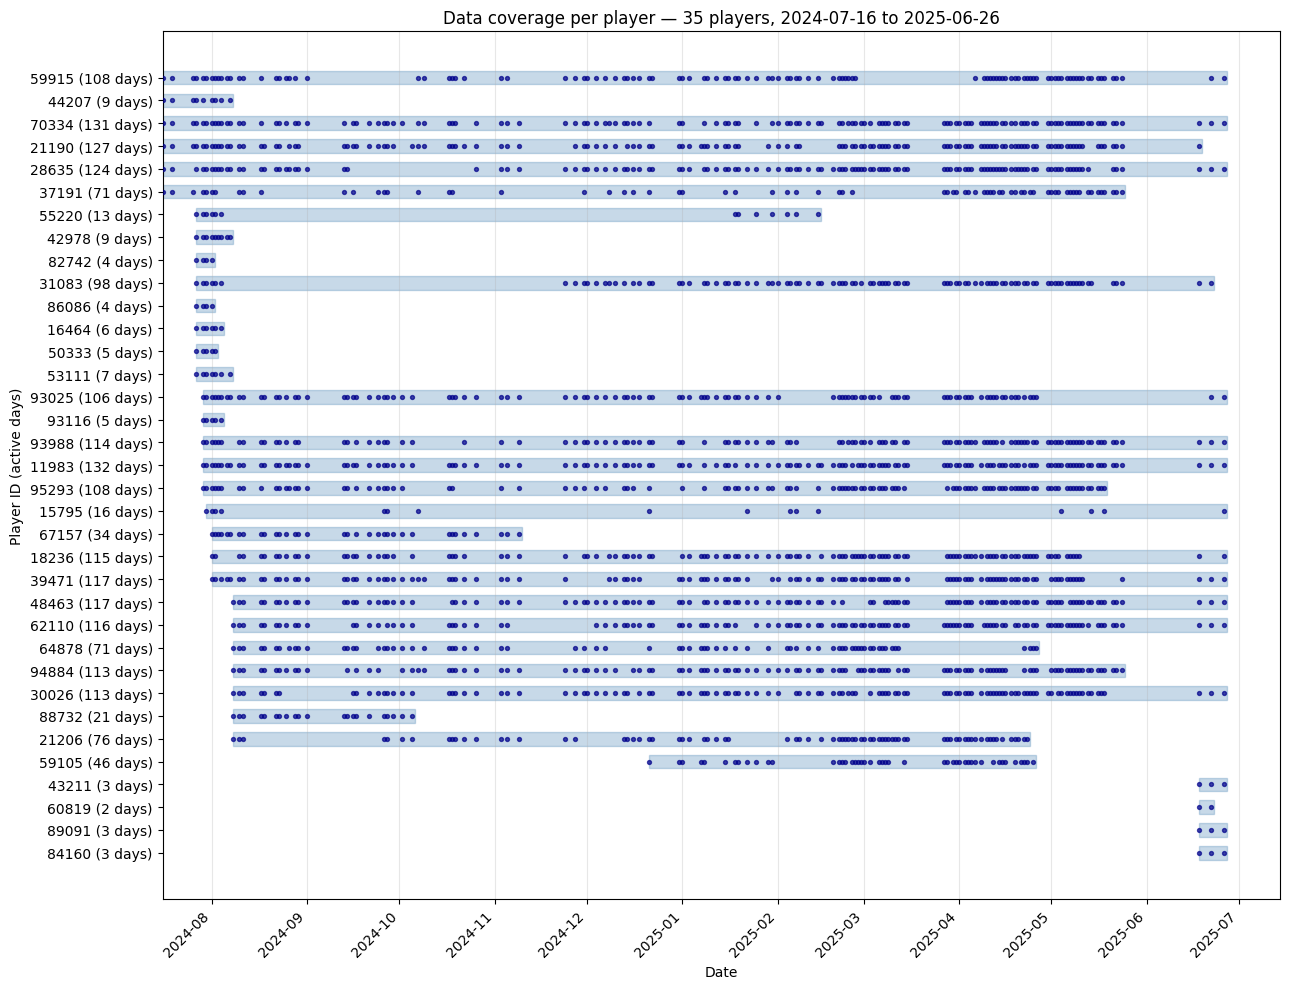

   player_id first_date  last_date  n_days  n_rows
0      59915 2024-07-16 2025-06-26     108     204
1      44207 2024-07-16 2024-08-07       9      24
2      70334 2024-07-16 2025-06-26     131     245
3      21190 2024-07-16 2025-06-18     127     237
4      28635 2024-07-16 2025-06-26     124     223
5      37191 2024-07-16 2025-05-24      71     168
6      55220 2024-07-27 2025-02-14      13      30
7      42978 2024-07-27 2024-08-07       9      21
8      82742 2024-07-27 2024-08-01       4      12
9      31083 2024-07-27 2025-06-22      98     174
10     86086 2024-07-27 2024-08-01       4      10
11     16464 2024-07-27 2024-08-04       6      20
12     50333 2024-07-27 2024-08-02       5      19
13     53111 2024-07-27 2024-08-07       7      17
14     93025 2024-07-29 2025-06-26     106     177
15     93116 2024-07-29 2024-08-04       5      16
16     93988 2024-07-29 2025-06-26     114     221
17     11983 2024-07-29 2025-06-26     132     232
18     95293 2024-07-29 2025-05

In [132]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_player_date_ranges(df, date_col='period_start_time', player_col='player_id',
                             figsize=(13, 10), show_activity=True):
    
    # Ensure date column is datetime
    dates = pd.to_datetime(df[date_col])
    
    # Get first and last date per player, and sort by first date so the chart reads nicely
    summary = df.assign(_date=dates).groupby(player_col, observed=True).agg(
        first_date=('_date', 'min'),
        last_date=('_date', 'max'),
        n_days=('_date', 'nunique'),
        n_rows=('_date', 'count'),
    ).sort_values('first_date').reset_index()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # One horizontal bar per player showing their activity window
    for i, row in summary.iterrows():
        ax.barh(y=i, 
                width=(row['last_date'] - row['first_date']).days + 1,
                left=row['first_date'],
                height=0.6,
                color='steelblue', alpha=0.3, edgecolor='steelblue')
        
        # Overlay individual activity dates as dots
        if show_activity:
            player_dates = dates[df[player_col] == row[player_col]].unique()
            ax.scatter(player_dates, [i] * len(player_dates),
                       s=8, color='darkblue', alpha=0.7, zorder=3)
    
    # Y-axis: player IDs, ordered by first appearance
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels([f"{pid} ({n} days)" for pid, n in 
                        zip(summary[player_col], summary['n_days'])])
    ax.set_xlabel('Date')
    ax.set_ylabel('Player ID (active days)')
    ax.set_title(f'Data coverage per player — {len(summary)} players, '
                 f'{dates.min().date()} to {dates.max().date()}')
    
    # Format x-axis with monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax.grid(True, axis='x', alpha=0.3)
    ax.invert_yaxis()  # first-appearing player at top
    
    plt.tight_layout()
    plt.show()
    
    return summary


# Run it on your cleaned row-level dataframe (after exclusions)
summary = plot_player_date_ranges(df)
print(summary)

## 1.5 Exclude players with missing metadata

One player (ID 50333) appears only during the first week of preseason with no anthropometric or positional metadata whatsoever. Without height, weight, position, or date of birth, this player cannot be featurised and is excluded via a `dropna` on those columns.

In [133]:
# Before dropping, document what you're removing and why
affected = df[df['height'].isna()]
print(f"Dropping {len(affected)} rows ({len(affected)/len(df):.2%}) "
      f"from {affected['player_id'].nunique()} player(s) with no metadata")

df = df.dropna(subset=['height', 'weight', 'position_name_en', 'date_of_birth']).reset_index(drop=True)

assert df.isna().sum().sum() == 0 or df.isna().sum()[df.isna().sum() > 0].index.tolist() == []
# or more explicit:
assert df[['player_id', 'height', 'weight', 'position_name_en', 'date_of_birth']].isna().sum().sum() == 0

Dropping 19 rows (0.49%) from 1 player(s) with no metadata


# 2. Outlier Detection and Treatment

We inspect the numeric column distributions and investigate extreme values before finalising the clean dataset.

In [134]:
df.describe()

,period_start_time,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,age
count,3884,3884.000000,3884.000000,3884.000000,3884.000000,3884.000000,3884.000000,3884,3884.000000
mean,2025-01-11 01:36:23.728115456,0.250000,1335.787003,4.980690,13.381160,176.972451,75.903193,1998-08-06 12:03:20.205973248,26.418126
min,2024-07-16 00:00:00,0.000000,44.093973,0.000000,0.000000,169.000000,64.000000,1969-01-16 00:00:00,17.000000
25%,2024-09-28 12:00:00,0.000000,713.652944,2.000000,0.000000,173.000000,67.000000,1996-07-28 00:00:00,23.000000
50%,2025-02-07 00:00:00,0.000000,1170.381759,5.000000,1.300446,177.000000,71.000000,1999-03-09 00:00:00,26.000000
75%,2025-04-12 00:00:00,0.250000,1676.451363,7.000000,20.953205,181.000000,79.000000,2002-03-24 00:00:00,29.000000
max,2025-06-26 00:00:00,1.000000,32299.892493,27.000000,191.200596,195.000000,200.000000,2007-09-02 00:00:00,56.000000
std,NaN,0.433068,1043.734660,3.772078,20.737091,5.486529,19.355849,NaN,5.867605


Three anomalies are visible in `describe()`:

- **`total_distance = 32,299 m`** — physiologically impossible for a single period (professional matches are ~10–12 km total).
- **`weight = 200`** — implausible; matches a known placeholder seen in suspect player records.
- **`date_of_birth` min = 1969 / `age` max = 56** — no active first-team player is 56 years old.

We address each anomaly below.

## 2.1 Anomalous `total_distance` — player 94884, 2025-02-15

Only `total_distance` is anomalous for this single MATCH row; the acceleration and HSR values (`acc = 15`, `hsr = 23.5 m`) are within normal match ranges. This points to a GPS export/parsing error on a single field, not a sensor malfunction.

In [135]:
df.sort_values(by='total_distance', ascending=False).head()

,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,exercise_type,age
3765,94884,period_1501,MATCH,activity_3585,2025-02-15,Forward,1.0,32299.892493,15,23.465222,175.0,78.0,1998-07-14,MATCH,27.0
2152,11983,period_3493,MATCH,activity_1612,2024-12-10,Central Midfielder,1.0,11093.472232,4,2.068091,172.0,66.0,1985-11-07,MATCH,39.0
1328,21190,period_2160,MATCH,activity_26,2025-04-13,Full Back,1.0,8163.381856,11,47.841802,173.0,71.0,1991-03-18,MATCH,34.0
2903,93988,period_934,TAC 2764,activity_3073,2025-05-06,Central Midfielder,0.0,7986.864611,2,54.079530,170.0,70.0,2005-05-31,TAC,20.0
1884,48463,period_4655,MATCH,activity_1778,2024-09-21,Central Midfielder,1.0,7831.834147,3,56.349076,181.0,77.0,1998-03-22,MATCH,27.0


The anomaly is isolated to one row for player 94884 (Forward). We subset this player's official match records to inspect the full distance distribution.

In [136]:
df_94884 = df[(df['player_id']==94884) & (df['is_official_match']==True)]

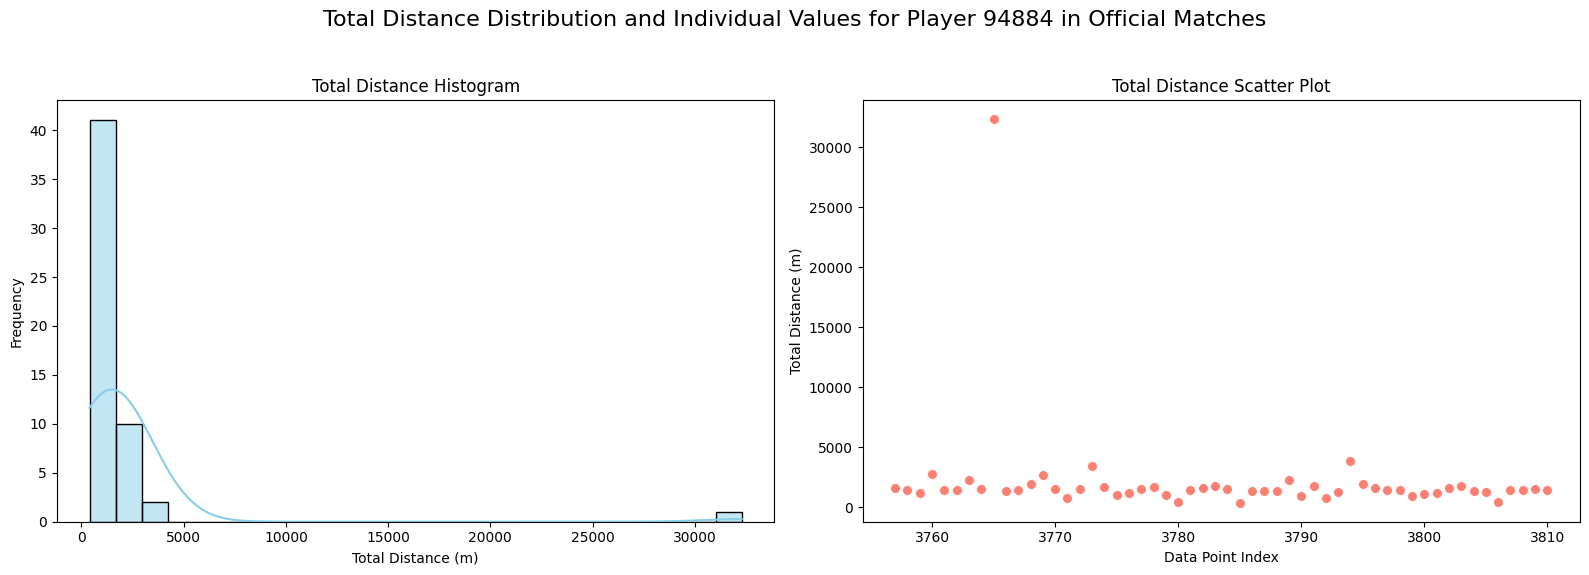

In [137]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Total Distance Distribution and Individual Values for Player 94884 in Official Matches", fontsize=16)

# Histogram for total_distance using Seaborn
sns.histplot(df_94884['total_distance'], bins=25, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Total Distance Histogram")
axes[0].set_xlabel("Total Distance (m)")
axes[0].set_ylabel("Frequency")

# Scatter plot for total_distance using Seaborn
sns.scatterplot(x=df_94884.index, y=df_94884['total_distance'], ax=axes[1], color='salmon', s=50)
axes[1].set_title("Total Distance Scatter Plot")
axes[1].set_xlabel("Data Point Index")
axes[1].set_ylabel("Total Distance (m)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Excluding the outlier, the distribution of match distances for player 94884 is unimodal and well-behaved. The **median** is used as the replacement value — it is robust to skew and avoids inventing a point estimate that coaches would treat as real data.

Mean of total_distance (excluding outlier): 1520.16 m
Median of total_distance (excluding outlier): 1461.14 m
Mode of total_distance (excluding outlier): 393.73 m


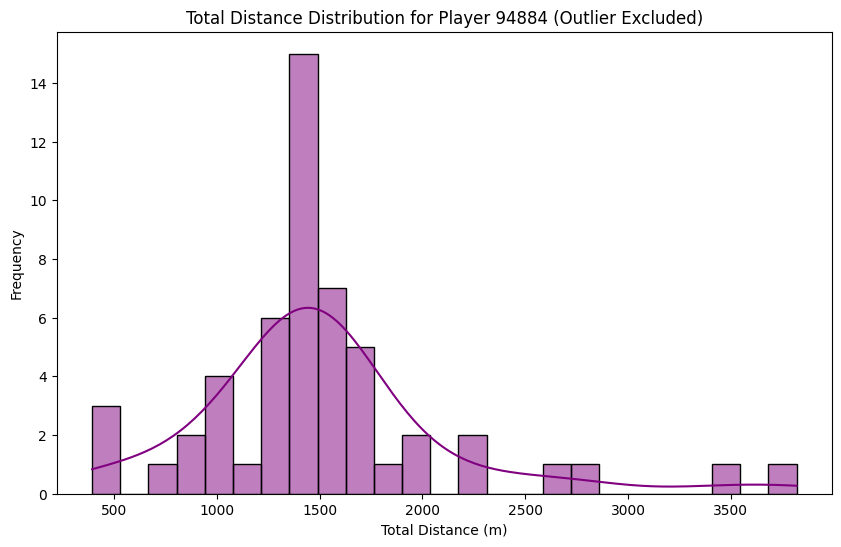

In [138]:
df_94884_filtered = df_94884[df_94884['total_distance'] <= 20000]

# Calculate mean, median, mode for the filtered data
mean_distance = df_94884_filtered['total_distance'].mean()
median_distance = df_94884_filtered['total_distance'].median()
mode_distance = df_94884_filtered['total_distance'].mode()[0] # .mode() can return multiple values, so take the first

print(f"Mean of total_distance (excluding outlier): {mean_distance:.2f} m")
print(f"Median of total_distance (excluding outlier): {median_distance:.2f} m")
print(f"Mode of total_distance (excluding outlier): {mode_distance:.2f} m")

# Plot histogram for the filtered data using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_94884_filtered['total_distance'], bins=25, kde=True, color='purple')
plt.title("Total Distance Distribution for Player 94884 (Outlier Excluded)")
plt.xlabel("Total Distance (m)")
plt.ylabel("Frequency")
plt.show()

Replace the anomalous value with the player's median match distance (computed above) and verify the fix.

In [139]:
df.loc[(df['player_id'] == 94884) & (df['total_distance'] >= 20000), 'total_distance'] = median_distance

# Verify the change
print("Value after replacement:")
print(df[(df['player_id'] == 94884) & (df['period_start_time'] == '2025-02-15')][['total_distance']])

Value after replacement:
      total_distance
3765     1461.144621


In [140]:
# Verify the bad row is actually fixed
print(df.loc[(df['player_id'] == 94884) & (df['period_start_time'] == '2025-02-15'), 
             ['total_distance', 'acc_band7plus_total_effort_count', 
              'velocity_band6plus7_total_distance']])

# Check: any remaining total_distance > 20000 anywhere?
print(f"Rows with total_distance > 20000: {(df['total_distance'] > 20000).sum()}")

      total_distance  acc_band7plus_total_effort_count  \
3765     1461.144621                                15   

      velocity_band6plus7_total_distance  
3765                           23.465222  
Rows with total_distance > 20000: 0


## 2.2 Suspect Player Profiles — Trialists and Placeholder Metadata

The 1969 birth year and `weight = 200` placeholder flag several players as likely trialists or academy call-ups whose metadata was not properly populated. We audit each before deciding to exclude or retain.

In [141]:
weight_200 = df[df['weight']==200].player_id.unique()

weight_200

[42978, 93116, 86086, 15795, 60819, 89091]
Categories (35, int64): [11983, 15795, 16464, 18236, ..., 93116, 93988, 94884, 95293]

In [142]:
for pid in weight_200:
    rows = df[df['player_id'] == pid]
    print(f"Player {pid}: {len(rows)} rows, "
          f"{rows['period_start_time'].min().date()} to {rows['period_start_time'].max().date()}, "
          f"DOB: {rows['date_of_birth'].iloc[0].date()}")

Player 42978: 21 rows, 2024-07-27 to 2024-08-07, DOB: 1969-01-16
Player 93116: 16 rows, 2024-07-29 to 2024-08-04, DOB: 2007-09-02
Player 86086: 10 rows, 2024-07-27 to 2024-08-01, DOB: 1969-12-05
Player 15795: 30 rows, 2024-07-30 to 2025-06-26, DOB: 2005-06-02
Player 60819: 2 rows, 2025-06-18 to 2025-06-22, DOB: 2003-02-06
Player 89091: 3 rows, 2025-06-18 to 2025-06-26, DOB: 2004-01-10


In [143]:
# Drop preseason/end-of-season trialists with placeholder biometrics or insufficient data
trialists_to_drop = weight_200
before = len(df)
df = df[~df['player_id'].isin(trialists_to_drop)].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows across {len(trialists_to_drop)} players")

# Sanity check — no more placeholder biometrics anywhere
assert ((df['height'] == 180) & (df['weight'] == 200)).sum() == 0
assert df['weight'].max() <= 100, "Unexpectedly high weight remaining"
assert df['date_of_birth'].dt.year.min() >= 1980, "Unexpectedly old DOB remaining"
print(f"Final dataset: {len(df)} rows, {df['player_id'].nunique()} players")

Dropped 82 rows across 6 players
Final dataset: 3802 rows, 28 players


# 3. Daily Aggregation

The raw data is at *period level* (one row per drill within a session). ACWR requires *daily* load totals. We aggregate to one row per `(player_id, date)`, preserving session composition via pivoted period counts and per-type load columns.

In [144]:
EXERCISE_TYPES = df.exercise_type.unique()
LOAD_COLS = ['total_distance', 'acc_band7plus_total_effort_count', 'velocity_band6plus7_total_distance']

## 3.1 Aggregate to daily

For each player-day:
- **Load totals** (`total_distance`, `acc_total`, `hsr_total`) — summed across all periods.
- **Exercise type set** (`exercise_types`) — frozenset of exercise categories that occurred (e.g. `{'G', 'TAC', 'BP'}`); preserves session composition without creating per-type columns.
- **Static metadata** (position, height, weight, DOB) — `first` value (constant per player).

In [145]:
def aggregate_to_daily(df):
    """
    Aggregate row-level periods into player-day rows.
    Exercise type composition is captured as a frozenset, not pivoted columns.
    """
    # 1. Daily totals across all periods
    totals = df.groupby(['player_id', 'period_start_time'], observed=True).agg(
        total_distance=('total_distance', 'sum'),
        acc_total=('acc_band7plus_total_effort_count', 'sum'),
        vel_total=('velocity_band6plus7_total_distance', 'sum'),
        is_match=('is_official_match', 'max'),
        n_periods=('activity_id', 'count'),
    ).reset_index()

    # 2. Set of exercise types that occurred on each player-day
    exercise_sets = (
        df.groupby(['player_id', 'period_start_time'], observed=True)['exercise_type']
        .apply(frozenset)
        .reset_index()
        .rename(columns={'exercise_type': 'exercise_types'})
    )

    # 3. Static per-player metadata (constant within a player)
    static = df.groupby('player_id', observed=True).agg(
        position_name_en=('position_name_en', 'first'),
        height=('height', 'first'),
        weight=('weight', 'first'),
        date_of_birth=('date_of_birth', 'first'),
    ).reset_index()

    # 4. Merge everything on player-day
    daily = (
        totals
        .merge(exercise_sets, on=['player_id', 'period_start_time'], how='left')
        .merge(static,        on='player_id',           how='left')
    )

    # 5. Recompute age at each row's date
    daily['age'] = (daily['period_start_time'] - daily['date_of_birth']).dt.days / 365.25

    # 6. Sanity check
    assert len(daily) == df.groupby(['player_id', 'period_start_time'], observed=True).ngroups, "Row count mismatch"

    return daily.sort_values(['player_id', 'period_start_time']).reset_index(drop=True)


daily = aggregate_to_daily(df)
print(f"Shape: {daily.shape}")
print(f"Columns: {daily.columns.tolist()}")
daily.head()

Shape: (2103, 13)
Columns: ['player_id', 'period_start_time', 'total_distance', 'acc_total', 'vel_total', 'is_match', 'n_periods', 'exercise_types', 'position_name_en', 'height', 'weight', 'date_of_birth', 'age']


,player_id,period_start_time,total_distance,acc_total,vel_total,is_match,n_periods,exercise_types,position_name_en,height,weight,date_of_birth,age
0,11983,2024-07-29,3751.549912,22,81.922951,0.0,3,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.724162
1,11983,2024-07-30,6059.586836,14,0.000000,0.0,3,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.726899
2,11983,2024-08-01,5182.181222,9,59.335029,1.0,5,"(MATCH, BP, TEC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.732375
3,11983,2024-08-02,2842.762421,7,37.537185,0.0,3,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.735113
4,11983,2024-08-03,1479.106082,3,20.534596,1.0,1,(MATCH),Central Midfielder,172.0,66.0,1985-11-07,38.737851


## 3.2 Full Calendar Grid

EWMA computation requires a **continuous daily series**. Gaps (rest days with no recorded activity) would distort the chronic load baseline and artificially inflate ACWR. We expand each player's timeline from their first observed session to their **last observed active date**, filling missing days with zero load and flagging them with `is_rest = 1`.

In [146]:
def expand_to_full_grid(daily, end_date=None):
    """
    Expand each player's timeline to a continuous daily grid.
    - Start: player's first observed day
    - End: player's last observed active day (prevents fake rest-day tail for
      mid-season transfers / loan departures).
      Pass end_date to override with a fixed date for all players (e.g. at inference time).
    - Missing days filled with zero load, is_rest=1, exercise_types=frozenset().
    """
    pieces = []
    for pid, g in daily.groupby('player_id', observed=True):
        start = g['period_start_time'].min()
        # Per-player end: last day with recorded load; avoids artificial chronic collapse
        player_end = end_date if end_date is not None else g['period_start_time'].max()
        full_dates = pd.date_range(start=start, end=player_end, freq='D')
        full = pd.DataFrame({'player_id': pid, 'period_start_time': full_dates})
        merged = full.merge(g, on=['player_id', 'period_start_time'], how='left')
        pieces.append(merged)

    out = pd.concat(pieces, ignore_index=True)

    # Zero-fill numeric load columns on rest days
    zero_fill_cols = ['total_distance', 'acc_total', 'vel_total', 'is_match', 'n_periods']
    out[zero_fill_cols] = out[zero_fill_cols].fillna(0)

    # exercise_types: empty frozenset on rest days
    out['exercise_types'] = out['exercise_types'].apply(
        lambda x: x if isinstance(x, frozenset) else frozenset()
    )

    # Rest-day flag
    out['is_rest'] = (out['n_periods'] == 0).astype(int)

    # Running count of consecutive rest days per player (resets to 0 on active days)
    out = out.sort_values(['player_id', 'period_start_time']).reset_index(drop=True)
    out['rest_streak'] = (
        out.groupby('player_id', observed=True)['is_rest']
        .transform(lambda s: s * (s.groupby((s != s.shift()).cumsum()).cumcount() + 1))
    )

    # Forward-fill static metadata (constant per player, NaN on rest days after merge)
    static_cols = ['position_name_en', 'height', 'weight', 'date_of_birth']
    out[static_cols] = out.groupby('player_id', observed=True)[static_cols].ffill().bfill()

    # Recompute age at each row's date
    out['age'] = (out['period_start_time'] - out['date_of_birth']).dt.days / 365.25

    return out.sort_values(['player_id', 'period_start_time']).reset_index(drop=True)


full_grid = expand_to_full_grid(daily)
print(f"Shape: {full_grid.shape}")
print(f"Rest days: {full_grid['is_rest'].sum()} / {len(full_grid)} "
      f"({full_grid['is_rest'].mean():.1%})")
print(f"Date range: {full_grid['period_start_time'].min().date()} → {full_grid['period_start_time'].max().date()}")
print(f"Players: {full_grid['player_id'].nunique()}")
full_grid.head()

Shape: (6310, 15)
Rest days: 4207 / 6310 (66.7%)
Date range: 2024-07-16 → 2025-06-26
Players: 28


,player_id,period_start_time,total_distance,acc_total,vel_total,is_match,n_periods,exercise_types,position_name_en,height,weight,date_of_birth,age,is_rest,rest_streak
0,11983,2024-07-29,3751.549912,22.0,81.922951,0.0,3.0,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.724162,0,0
1,11983,2024-07-30,6059.586836,14.0,0.000000,0.0,3.0,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.726899,0,0
2,11983,2024-07-31,0.000000,0.0,0.000000,0.0,0.0,(),Central Midfielder,172.0,66.0,1985-11-07,38.729637,1,1
3,11983,2024-08-01,5182.181222,9.0,59.335029,1.0,5.0,"(MATCH, BP, TEC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.732375,0,0
4,11983,2024-08-02,2842.762421,7.0,37.537185,0.0,3.0,"(BP, TAC, G)",Central Midfielder,172.0,66.0,1985-11-07,38.735113,0,0


**Why per-player end dates matter:** Extending every player to the global season end inflates the rest-day tail for mid-season transfers and loan departures. A player who left in January would accumulate five months of zero-load days, driving their EWMA chronic baseline toward zero. If that player later appeared at inference time, the ACWR would look artificially elevated — not because of a real workload spike, but because the denominator had collapsed. Using per-player end dates keeps each player's chronic baseline anchored to their actual last training block.

In [147]:
full_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6310 entries, 0 to 6309
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   player_id          6310 non-null   object        
 1   period_start_time  6310 non-null   datetime64[ns]
 2   total_distance     6310 non-null   float64       
 3   acc_total          6310 non-null   float64       
 4   vel_total          6310 non-null   float64       
 5   is_match           6310 non-null   float64       
 6   n_periods          6310 non-null   float64       
 7   exercise_types     6310 non-null   object        
 8   position_name_en   6310 non-null   object        
 9   height             6310 non-null   float64       
 10  weight             6310 non-null   float64       
 11  date_of_birth      6310 non-null   datetime64[ns]
 12  age                6310 non-null   float64       
 13  is_rest            6310 non-null   int64         
 14  rest_str

## 3.3 Grid Diagnostics

Verify grid integrity and inspect session composition patterns across the squad.

In [148]:
# 1. One player's first 10 days — should show training days + rest days
pid = full_grid['player_id'].iloc[0]
full_grid[full_grid['player_id'] == pid].head(10)[
    ['period_start_time', 'total_distance', 'is_rest', 'exercise_types']
]

# 2. Active-day summary
active = full_grid[full_grid['is_rest'] == 0]
print(f"\nActive days: {len(active)}")
print(active[['total_distance', 'acc_total', 'vel_total']].describe())

# 3. Exercise-type breakdown on active days only
print("\nFraction of active days each type appears:")
for t in EXERCISE_TYPES:
    pct = active['exercise_types'].apply(lambda s: t in s).mean()
    print(f"  {t}: {pct:.1%}")


Active days: 2103
       total_distance    acc_total    vel_total
count     2103.000000  2103.000000  2103.000000
mean      2399.148285     9.030908    24.352155
std       1650.419834     6.608280    27.954954
min         44.093973     0.000000     0.000000
25%       1315.060592     5.000000     0.000834
50%       1898.105081     7.000000    16.273324
75%       3148.420100    12.000000    36.562463
max      11552.250759    48.000000   244.337506

Fraction of active days each type appears:
  BP: 24.4%
  G: 45.9%
  TAC: 32.6%
  TEC: 11.7%
  MATCH: 44.0%


### Exercise type frequency on active days

In [149]:
# How often does each type appear on an active day?
active = full_grid[full_grid['is_rest'] == 0]
for t in EXERCISE_TYPES:
    pct_days = active['exercise_types'].apply(lambda s: t in s).mean()
    print(f"{t}: appears on {pct_days:.1%} of active days")

BP: appears on 24.4% of active days
G: appears on 45.9% of active days
TAC: appears on 32.6% of active days
TEC: appears on 11.7% of active days
MATCH: appears on 44.0% of active days


### Common training day compositions (non-match days)

In [150]:
active_nonmatch = full_grid[(full_grid['is_rest'] == 0) & (full_grid['is_match'] == 0)]
combo = active_nonmatch['exercise_types'].apply(
    lambda s: '+'.join(sorted(s - {'MATCH'})) or 'none'
)
print(combo.value_counts().head(10))

exercise_types
G+TAC        336
BP+G         158
BP+G+TAC     148
G            117
TAC           92
BP+G+TEC      86
G+TEC         60
BP            51
G+TAC+TEC     47
BP+TAC        37
Name: count, dtype: int64


### Player data sufficiency
Players with very few active days cannot reliably support a load prediction model. The cohort exhibits a clear bimodal split: regular squad members (71+ active days) and irregular contributors (≤46 active days), with no players in the 47-70 range. We use a threshold of 50 active days, which falls inside the natural gap and matches conventional minimum sample sizes for stable per-player parameter estimation in hierarchical models. Players below this threshold are flagged as non-modelable and will receive a position-based fallback at inference time.

In [151]:
player_stats = full_grid.groupby('player_id', observed=True).agg(
    active_days=('is_rest', lambda s: (s == 0).sum()),
    grid_days=('period_start_time', 'count'),
    max_streak=('rest_streak', 'max'),
).reset_index()
player_stats['activity_rate'] = player_stats['active_days'] / player_stats['grid_days']

# Identify modelable cohort: players with enough active days for stable
# per-player parameter estimation. Threshold of 50 falls inside the natural
# gap in the data (no players between 46-71 active days) and matches
# conventional minimum sample sizes for hierarchical/per-group models.
MIN_ACTIVE_DAYS_FOR_MODELING = 50

player_stats = full_grid.groupby('player_id', observed=True).agg(
    active_days=('is_rest', lambda s: (s == 0).sum()),
    grid_days=('period_start_time', 'count'),
    max_streak=('rest_streak', 'max'),
).reset_index()
player_stats['activity_rate'] = player_stats['active_days'] / player_stats['grid_days']
player_stats['is_modelable'] = player_stats['active_days'] >= MIN_ACTIVE_DAYS_FOR_MODELING

full_grid = full_grid.merge(
    player_stats[['player_id', 'activity_rate', 'is_modelable']],
    on='player_id', how='left'
)

print(f"Modelable players: {player_stats['is_modelable'].sum()} / {len(player_stats)} "
      f"(threshold: {MIN_ACTIVE_DAYS_FOR_MODELING} active days)")
print(player_stats.sort_values('active_days'))

Modelable players: 18 / 28 (threshold: 50 active days)
    player_id  active_days  grid_days  max_streak  activity_rate  is_modelable
22      84160            3          9           3       0.333333         False
10      43211            3          9           3       0.333333         False
21      82742            4          6           1       0.666667         False
1       16464            6          9           1       0.666667         False
13      53111            7         12           2       0.583333         False
11      44207            9         23           6       0.391304         False
14      55220           13        203         166       0.064039         False
23      88732           21         59          11       0.355932         False
19      67157           34        101          11       0.336634         False
15      59105           46        126          19       0.365079         False
8       37191           71        313          29       0.226837          Tr

Daily Load Distribution by Position

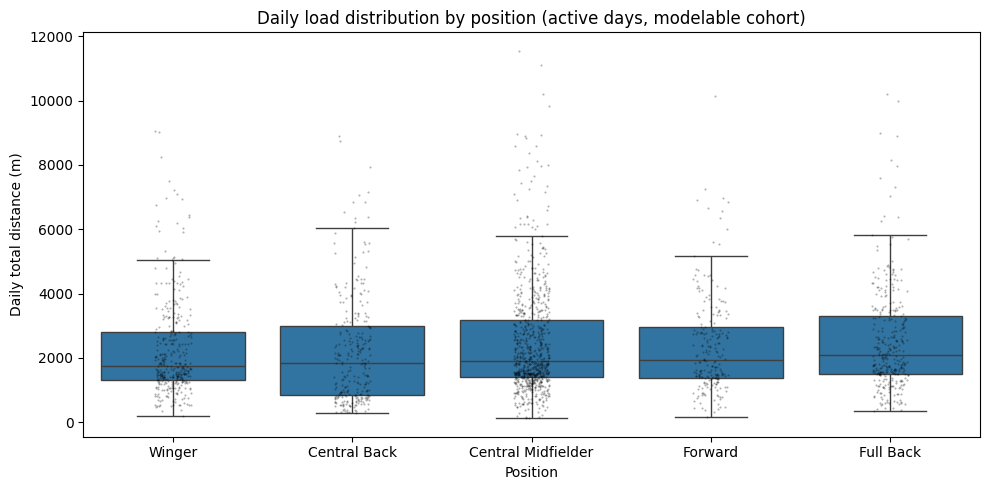

                    count  median    mean     std
position_name_en                                 
Winger                356  1740.0  2262.0  1514.0
Central Back          275  1848.0  2194.0  1693.0
Central Midfielder    776  1892.0  2462.0  1678.0
Forward               221  1932.0  2371.0  1506.0
Full Back             329  2092.0  2540.0  1611.0


In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Active days, modelable cohort only
plot_df = full_grid[(full_grid['is_rest'] == 0) & (full_grid['is_modelable'])].copy()

# Order positions by median load (so the plot reads left-to-right meaningfully)
position_order = (plot_df.groupby('position_name_en', observed=True)['total_distance']
                         .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x='position_name_en', y='total_distance',
            order=position_order, ax=ax, showfliers=False)
sns.stripplot(data=plot_df, x='position_name_en', y='total_distance',
              order=position_order, ax=ax, size=1.5, alpha=0.3, color='black')
ax.set_xlabel('Position')
ax.set_ylabel('Daily total distance (m)')
ax.set_title('Daily load distribution by position (active days, modelable cohort)')
plt.tight_layout()
plt.show()

# Numerical companion
summary = (plot_df.groupby('position_name_en', observed=True)['total_distance']
                  .agg(['count', 'median', 'mean', 'std'])
                  .round(0).sort_values('median'))
print(summary)

Daily Load Distribution by Exercise Archetype

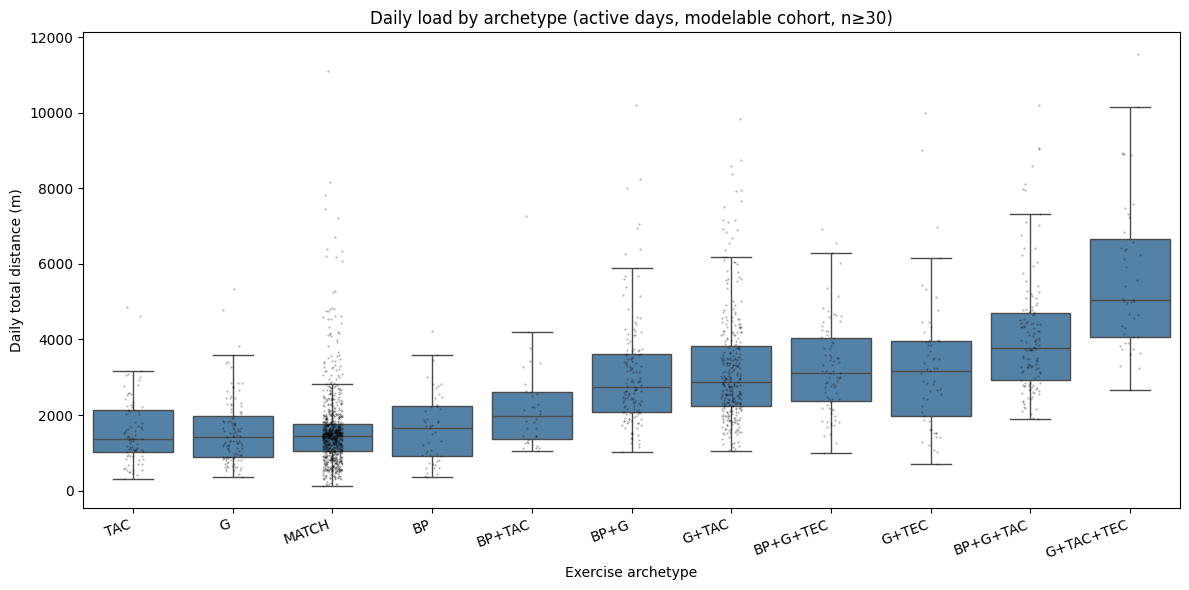

           count  median    mean     std
archetype                               
TAC           86  1374.0  1582.0   872.0
G            113  1427.0  1584.0   889.0
MATCH        859  1459.0  1596.0  1031.0
BP            49  1657.0  1652.0   932.0
BP+TAC        34  1971.0  2220.0  1217.0
BP+G         141  2744.0  3112.0  1481.0
G+TAC        317  2871.0  3243.0  1501.0
BP+G+TEC      79  3124.0  3272.0  1244.0
G+TEC         57  3172.0  3296.0  1796.0
BP+G+TAC     130  3780.0  4113.0  1602.0
G+TAC+TEC     44  5035.0  5669.0  2023.0


In [153]:
# Active days, modelable cohort only
plot_df = full_grid[(full_grid['is_rest'] == 0) & (full_grid['is_modelable'])].copy()

# Convert frozenset → readable string label
plot_df['archetype'] = plot_df['exercise_types'].apply(lambda s: '+'.join(sorted(s)))

# Top archetypes by frequency (≥30 days)
arch_counts = plot_df['archetype'].value_counts()
top_archetypes = arch_counts[arch_counts >= 30].index.tolist()
plot_df_top = plot_df[plot_df['archetype'].isin(top_archetypes)]

# Order archetypes by median load
arch_order = (plot_df_top.groupby('archetype', observed=True)['total_distance']
                         .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=plot_df_top, x='archetype', y='total_distance',
            order=arch_order, ax=ax, showfliers=False, color='steelblue')
sns.stripplot(data=plot_df_top, x='archetype', y='total_distance',
              order=arch_order, ax=ax, size=1.5, alpha=0.3, color='black')
ax.set_xlabel('Exercise archetype'); ax.set_ylabel('Daily total distance (m)')
ax.set_title('Daily load by archetype (active days, modelable cohort, n≥30)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Numerical companion
summary = (plot_df_top.groupby('archetype', observed=True)['total_distance']
                      .agg(['count','median','mean','std'])
                      .round(0).sort_values('median'))
print(summary)

Seasonal Drift in Squad Wide Load

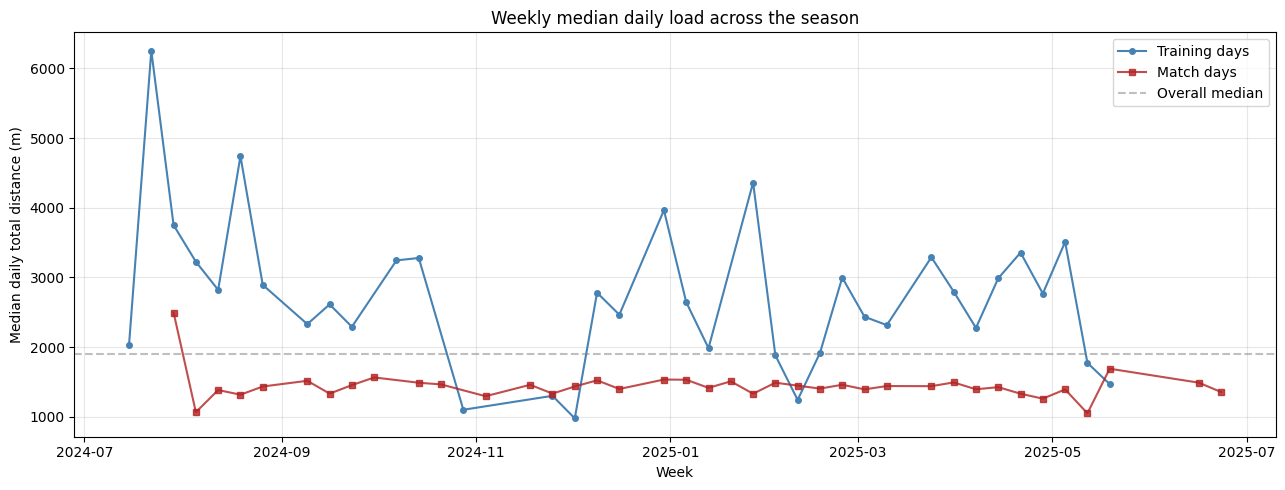

                       n  median
month      is_match             
2024-07-01 0.0        56  3734.0
2024-08-01 0.0       140  3243.0
           1.0        99  1490.0
2024-09-01 0.0        57  2522.0
           1.0        84  1451.0
2024-10-01 0.0        43  3279.0
           1.0        69  1501.0
2024-11-01 0.0        33  1217.0
           1.0        57  1379.0
2024-12-01 0.0        71  2668.0
           1.0        97  1456.0
2025-01-01 0.0        93  2926.0
           1.0       117  1517.0
2025-02-01 0.0       130  1924.0
           1.0       106  1425.0
2025-03-01 0.0       154  2599.0
           1.0        83  1441.0
2025-04-01 0.0       226  2905.0
           1.0       117  1394.0
2025-05-01 0.0       174  2543.0
           1.0        58  1300.0
2025-06-01 1.0        39  1483.0


In [154]:
import matplotlib.pyplot as plt

# Active days only (modelable cohort doesn't matter much here — we want squad-wide pattern)
plot_df = full_grid[full_grid['is_rest'] == 0].copy()
plot_df['week'] = plot_df['period_start_time'].dt.to_period('W').dt.start_time

# Squad-wide weekly aggregates
weekly = (plot_df.groupby(['week','is_match'], observed=True)
                 .agg(median_load=('total_distance', 'median'),
                      n_days=('total_distance', 'count'))
                 .reset_index())

# Pivot to one column per is_match value for plotting
training = weekly[weekly['is_match']==0]
matches  = weekly[weekly['is_match']==1]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(training['week'], training['median_load'], 'o-', label='Training days',
        color='steelblue', markersize=4, linewidth=1.5)
ax.plot(matches['week'], matches['median_load'], 's-', label='Match days',
        color='firebrick', markersize=4, linewidth=1.5, alpha=0.8)
ax.axhline(plot_df['total_distance'].median(), linestyle='--', color='gray',
           alpha=0.5, label='Overall median')
ax.set_xlabel('Week'); ax.set_ylabel('Median daily total distance (m)')
ax.set_title('Weekly median daily load across the season')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Phase summary table — bin by month
plot_df['month'] = plot_df['period_start_time'].dt.to_period('M').dt.start_time
monthly_summary = (plot_df.groupby(['month','is_match'], observed=True)
                          .agg(n=('total_distance','count'),
                               median=('total_distance','median'))
                          .round(0))
print(monthly_summary.to_string())

Metric Correlation

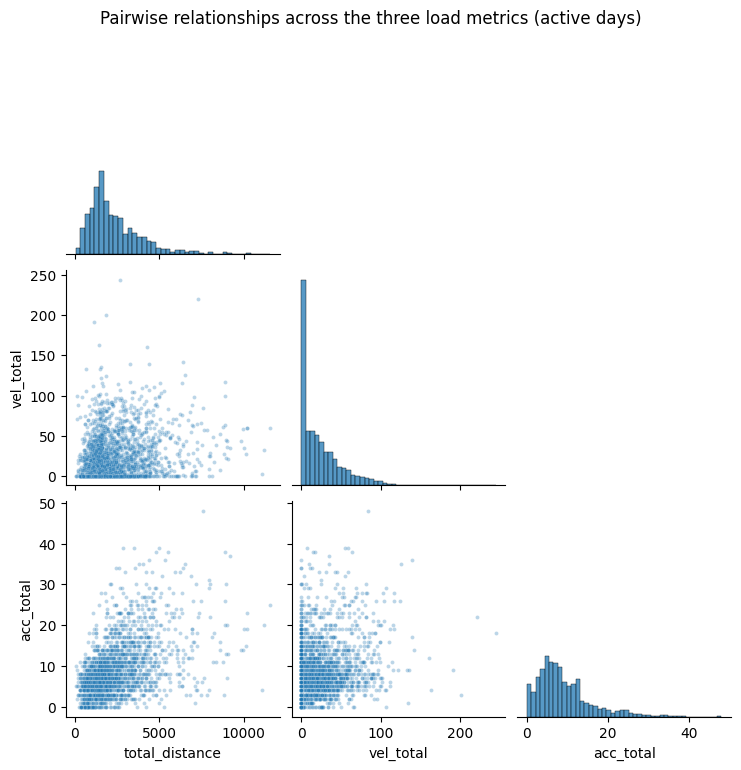

Pearson correlations:
                total_distance  vel_total  acc_total
total_distance           1.000      0.189      0.483
vel_total                0.189      1.000      0.218
acc_total                0.483      0.218      1.000

Spearman correlations (rank-based, robust to non-linearity):
                total_distance  vel_total  acc_total
total_distance           1.000      0.190      0.473
vel_total                0.190      1.000      0.217
acc_total                0.473      0.217      1.000


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

active = full_grid[full_grid['is_rest'] == 0].copy()

# Pairplot of the three metrics
g = sns.pairplot(active[['total_distance','vel_total','acc_total']],
                 plot_kws={'alpha': 0.3, 's': 8}, height=2.5, corner=True)
g.fig.suptitle('Pairwise relationships across the three load metrics (active days)', y=1.02)
plt.show()

# Correlation matrix — Pearson and Spearman side by side
metrics = ['total_distance','vel_total','acc_total']
pearson = active[metrics].corr(method='pearson').round(3)
spearman = active[metrics].corr(method='spearman').round(3)
print("Pearson correlations:")
print(pearson)
print("\nSpearman correlations (rank-based, robust to non-linearity):")
print(spearman)

The three metrics are largely independent. Pearson correlations of 0.19, 0.48, and 0.22 mean they're capturing genuinely different things. For comparison, sports science textbooks often discuss these metrics as related expressions of "external load" — and at squad level you'd expect them to correlate around 0.6-0.8. Yours don't. The decoupling is real.

* total_distance = volume of movement
* vel_total = exposure to high-speed efforts (sprint-specific)
* acc_total = neuromuscular load (deceleration / change of direction)

Pearson and Spearman match within ±0.02 across all pairs, which means the relationships don't have hidden non-linear structure. What you see in the scatter is what you get — no curved trends being missed by Pearson.

Persist the cleaned Datasets

In [157]:
from pathlib import Path
import pandas as pd

OUT = Path('./data/processed')
OUT.mkdir(parents=True, exist_ok=True)

# Make sure both frames have the string form
full_grid['archetype_str'] = full_grid['exercise_types'].apply(
    lambda s: '+'.join(sorted(s)) if len(s) else 'REST'
)
daily['archetype_str'] = daily['exercise_types'].apply(
    lambda s: '+'.join(sorted(s))
)

# Drop the frozenset column for serialization
full_grid.drop(columns='exercise_types').to_parquet(OUT / 'full_grid.parquet', index=False)
daily.drop(columns='exercise_types').to_parquet(OUT / 'daily.parquet', index=False)
player_stats.to_parquet(OUT / 'player_stats.parquet', index=False)

print("Saved.")

Saved.


# 4. EWMA-Based ACWR Computation

The Acute:Chronic Workload Ratio compares a player's recent load (acute, ~7 days) to their longer-term baseline (chronic, ~28 days). Values in **0.8–1.3** are generally considered safe; values above **1.5** signal elevated injury risk.

We use the **EWMA formulation** (Williams et al., 2017) — it weights recent sessions more heavily and handles rest-day decay more realistically than simple rolling averages:

```
acute[t]   = λ_a · load[t] + (1 − λ_a) · acute[t-1]     λ_a = 2/(7+1)  = 0.25
chronic[t] = λ_c · load[t] + (1 − λ_c) · chronic[t-1]   λ_c = 2/(28+1) ≈ 0.069
ACWR[t]    = acute[t] / chronic[t]
```

ACWR is computed **independently** for all three load metrics.

## 4.1 EWMA decay — understanding the smoothing parameter

With `λ_acute = 0.25`, the most recent 7 days account for ~87% of the acute load signal. Older sessions decay exponentially — a session 14 days ago contributes less than 2%.

In [67]:
lam = 0.25
weights = lam * (1 - lam) ** np.arange(20)
print(weights)
print(f"Sum of first 7: {weights[:7].sum():.3f}")  # should be close to 1
print(f"Sum of all: {weights.sum():.3f}")           # converges to 1 as t → ∞

[0.25       0.1875     0.140625   0.10546875 0.07910156 0.05932617
 0.04449463 0.03337097 0.02502823 0.01877117 0.01407838 0.01055878
 0.00791909 0.00593932 0.00445449 0.00334087 0.00250565 0.00187924
 0.00140943 0.00105707]
Sum of first 7: 0.867
Sum of all: 0.997


## 4.2 EWMA helper function

Initialised from zero (`EWMA[−1] = 0`). A zero is prepended before calling pandas `ewm` so the recursion starts from the correct initial state, then the artificial leading value is dropped.

In [68]:
def ewma(values, lam):
    s = pd.Series(np.concatenate([[0.0], np.asarray(values, dtype=float)]))
    result = s.ewm(alpha=lam, adjust=False).mean().values
    return result[1:]  # drop the artificial initial zero

## 4.3 Per-player ACWR computation

For each player's timeline:
- **Warmup masking**: first 28 days set to `NaN` — chronic EWMA needs ~28 days to converge from zero initialisation.
- **Division-by-zero**: `NaN` wherever `chronic == 0` (player has never trained; ratio is undefined).

In [69]:
def compute_acwr_for_player(daily_loads, warmup_days=28):
    """
    Compute EWMA-based acute load, chronic load, and ACWR for a single player,
    single load metric.

    Parameters
    ----------
    daily_loads : pd.Series
        Daily load values indexed by date. No gaps (rest days must be 0).
    warmup_days : int
        Number of initial days to mask as NaN (default 28).

    Returns
    -------
    pd.DataFrame with same index as daily_loads and columns:
        acute, chronic, acwr, is_warmup
    """
    # Smoothing parameters: lambda = 2 / (N + 1)
    lam_acute = 2 / (7 + 1)      # 0.25
    lam_chronic = 2 / (28 + 1)   # ~0.0690

    # Compute the two EWMA series using the ewma() function you already have
    acute = ewma(daily_loads.values, lam_acute)
    chronic = ewma(daily_loads.values, lam_chronic)

    # Safe division: NaN wherever chronic is 0 (undefined ratio)
    with np.errstate(divide='ignore', invalid='ignore'):
        acwr = np.where(chronic > 0, acute / chronic, np.nan)

    # Mask the warmup period — chronic EWMA hasn't stabilized yet
    is_warmup = np.arange(len(daily_loads)) < warmup_days
    acwr = np.where(is_warmup, np.nan, acwr)

    # Shape sanity check
    assert len(acute) == len(chronic) == len(acwr) == len(daily_loads)

    return pd.DataFrame({
        'acute': acute,
        'chronic': chronic,
        'acwr': acwr,
        'is_warmup': is_warmup,
    }, index=daily_loads.index)

## 4.4 Apply ACWR to the full grid

Iterates over all 29 players × 3 metrics, attaching `{metric}_acute`, `{metric}_chronic`, and `{metric}_acwr` columns to the grid. `is_warmup` is captured once (identical window for all metrics).

In [70]:
def add_acwr_to_grid(full_grid, metrics=None, warmup_days=28):
    """
    Compute EWMA-ACWR for every player × every load metric and attach to the grid.
    
    Parameters
    ----------
    full_grid : pd.DataFrame
        Must have columns: player_id, date, and the load metric columns.
        Must be a complete daily grid (rest days zero-filled).
    metrics : list of str, optional
        Load metric column names to process. Defaults to the three we use.
    warmup_days : int
        Passed to compute_acwr_for_player.
    
    Returns
    -------
    pd.DataFrame: full_grid with added columns per metric:
        {metric}_acute, {metric}_chronic, {metric}_acwr
        plus a single is_warmup column (same for all metrics).
    """
    if metrics is None:
        metrics = ['total_distance', 'acc_total', 'vel_total']
    
    # Sort by (player, date) so the EWMA recursion runs in chronological order
    out = full_grid.sort_values(['player_id', 'period_start_time']).reset_index(drop=True).copy()
    
    # We'll capture is_warmup once (it's identical across metrics — same warmup window)
    warmup_captured = False
    warmup_arrays = []
    
    for metric in metrics:
        acute_arrays = []
        chronic_arrays = []
        acwr_arrays = []
        
        for pid, g in out.groupby('player_id', observed=True, sort=False):
            series = g.set_index('period_start_time')[metric]
            res = compute_acwr_for_player(series, warmup_days=warmup_days)
            
            acute_arrays.append(res['acute'].values)
            chronic_arrays.append(res['chronic'].values)
            acwr_arrays.append(res['acwr'].values)
            
            if not warmup_captured:
                warmup_arrays.append(res['is_warmup'].values)
        
        out[f'{metric}_acute'] = np.concatenate(acute_arrays)
        out[f'{metric}_chronic'] = np.concatenate(chronic_arrays)
        out[f'{metric}_acwr'] = np.concatenate(acwr_arrays)
        
        warmup_captured = True  # only capture once
    
    out['is_warmup'] = np.concatenate(warmup_arrays)
    
    return out


full_grid = add_acwr_to_grid(full_grid)

# Sanity check
print(f"Shape: {full_grid.shape}")
print(f"New columns:", [c for c in full_grid.columns if 'acute' in c or 'chronic' in c or 'acwr' in c or 'warmup' in c])
print(f"\nACWR summary on ACTIVE days (post-warmup):")
active_post_warmup = full_grid[(full_grid['is_rest'] == 0) & (~full_grid['is_warmup'])]
for m in ['total_distance', 'acc_total', 'vel_total']:
    s = active_post_warmup[f'{m}_acwr']
    print(f"  {m}_acwr: median={s.median():.3f}, p25={s.quantile(0.25):.3f}, "
          f"p75={s.quantile(0.75):.3f}, p95={s.quantile(0.95):.3f}")

Shape: (6310, 27)
New columns: ['total_distance_acute', 'total_distance_chronic', 'total_distance_acwr', 'acc_total_acute', 'acc_total_chronic', 'acc_total_acwr', 'vel_total_acute', 'vel_total_chronic', 'vel_total_acwr', 'is_warmup']

ACWR summary on ACTIVE days (post-warmup):
  total_distance_acwr: median=1.298, p25=1.074, p75=1.572, p95=2.135
  acc_total_acwr: median=1.315, p25=1.072, p75=1.582, p95=2.108
  vel_total_acwr: median=1.204, p25=0.827, p75=1.578, p95=2.261


## 5. Off-Period and Layoff Features

Team-wide off-periods are different from individual rest. When 80%+ of the squad is inactive on a given date, the player isn't choosing to rest — the entire team is in an off-period (international break, end-of-season gap, etc.). This flag lets the model treat these periods differently from a player choosing to train lightly or recovering from a knock.

In [71]:
# is_team_off_period: date where >80% of all players in the grid have is_rest=1.
# Captures international breaks, mid-season gaps, and end-of-season periods.
daily_rest_rate = (
    full_grid.groupby('period_start_time')['is_rest']
    .mean()
    .reset_index()
    .rename(columns={'is_rest': 'squad_rest_rate'})
)
daily_rest_rate['is_team_off_period'] = daily_rest_rate['squad_rest_rate'] > 0.8

full_grid = full_grid.merge(daily_rest_rate[['period_start_time', 'is_team_off_period']], on='period_start_time', how='left')

n_off = daily_rest_rate['is_team_off_period'].sum()
n_total = len(daily_rest_rate)
print(f"Team-off days: {n_off} / {n_total} ({n_off / n_total:.1%})")

# Find and report the 5 longest consecutive team-off blocks
off_dates = daily_rest_rate[daily_rest_rate['is_team_off_period']].sort_values('period_start_time').copy()
off_dates['block'] = (off_dates['period_start_time'].diff() > pd.Timedelta('1D')).cumsum()
blocks = (
    off_dates.groupby('block')
    .agg(start=('period_start_time', 'min'), end=('period_start_time', 'max'), length=('period_start_time', 'count'))
    .sort_values('length', ascending=False)
)
print("\nLongest team-off periods (top 5):")
print(blocks.head(5).to_string(index=False))

Team-off days: 193 / 346 (55.8%)

Longest team-off periods (top 5):
     start        end  length
2025-05-25 2025-06-17      24
2024-11-10 2024-11-23      14
2025-03-16 2025-03-26      11
2024-09-02 2024-09-12      11
2024-12-23 2024-12-30       8


### 5.1 Player Layoff and Return Features

Individual rest streaks within team-active periods signal injury or personal leave. The following features distinguish a player's absence from squad-wide downtime and quantify the magnitude of load discontinuity on return.

In [72]:
full_grid = full_grid.sort_values(['player_id', 'period_start_time']).reset_index(drop=True)

# 1. days_since_last_active: days elapsed since the player's last active day.
#    Resets to 0 on active days; counts up during rest streaks.
def _days_since_active(s):
    result, count = [], 0
    for v in s:
        count = 0 if v == 0 else count + 1
        result.append(count)
    return result

full_grid['days_since_last_active'] = (
    full_grid.groupby('player_id', observed=True)['is_rest']
    .transform(_days_since_active)
)

# Shift per-player once; reused for features 2 and 3
_prev_days_off = (
    full_grid.groupby('player_id', observed=True)['days_since_last_active']
    .shift(1).fillna(0)
)

# 2. is_returning_from_layoff: True only on the first active day after 14+ rest days.
full_grid['is_returning_from_layoff'] = (full_grid['is_rest'] == 0) & (_prev_days_off >= 14)

# 3. layoff_streak_length: length of the preceding rest streak on return days (0 elsewhere).
#    Answers "how long was the layoff?" on the exact return day.
full_grid['layoff_streak_length'] = (
    np.where(full_grid['is_returning_from_layoff'], _prev_days_off, 0).astype(int)
)

# 4. cumulative_active_days_last_28: active days in the previous 28 days (exclusive of today).
#    Low values signal thin chronic-baseline data; useful as a model confidence flag.
full_grid['cumulative_active_days_last_28'] = (
    full_grid.groupby('player_id', observed=True)['is_rest']
    .transform(lambda s: (1 - s).rolling(28, min_periods=1).sum().shift(1).fillna(0))
    .astype(int)
)

# 5. personal_layoff_excluding_team_off: rest streak ≥7 days that is NOT covered by a
#    team-wide off-period — distinguishes individual absence (injury/illness) from squad rest.
full_grid['personal_layoff_excluding_team_off'] = (
    (full_grid['days_since_last_active'] >= 7) &
    (~full_grid['is_team_off_period'])
)

# Summary
returns = full_grid[full_grid['is_returning_from_layoff']]
print(f"Returning-from-layoff days: {len(returns)} across {returns['player_id'].nunique()} players")
print(f"\nlayoff_streak_length on return days:")
print(returns['layoff_streak_length'].describe().round(1).to_string())
print(f"\nMax days_since_last_active per player (top 5):")
print(
    full_grid.groupby('player_id', observed=True)['days_since_last_active']
    .max().sort_values(ascending=False).head(5).to_string()
)
print(f"\nPersonal layoff days (not team-wide): {full_grid['personal_layoff_excluding_team_off'].sum()}")

Returning-from-layoff days: 51 across 20 players

layoff_streak_length on return days:
count     51.0
mean      26.9
std       25.3
min       14.0
25%       14.0
50%       21.0
75%       27.0
max      166.0

Max days_since_last_active per player (top 5):
player_id
55220    166
31083    111
93025     56
21206     45
28635     41

Personal layoff days (not team-wide): 270


## 4.5 Trajectory visualisation

ACWR trajectories for the most active modelable player (post-warmup). Green band = safe zone (0.8–1.3); dashed red line = elevated-risk threshold (1.5).

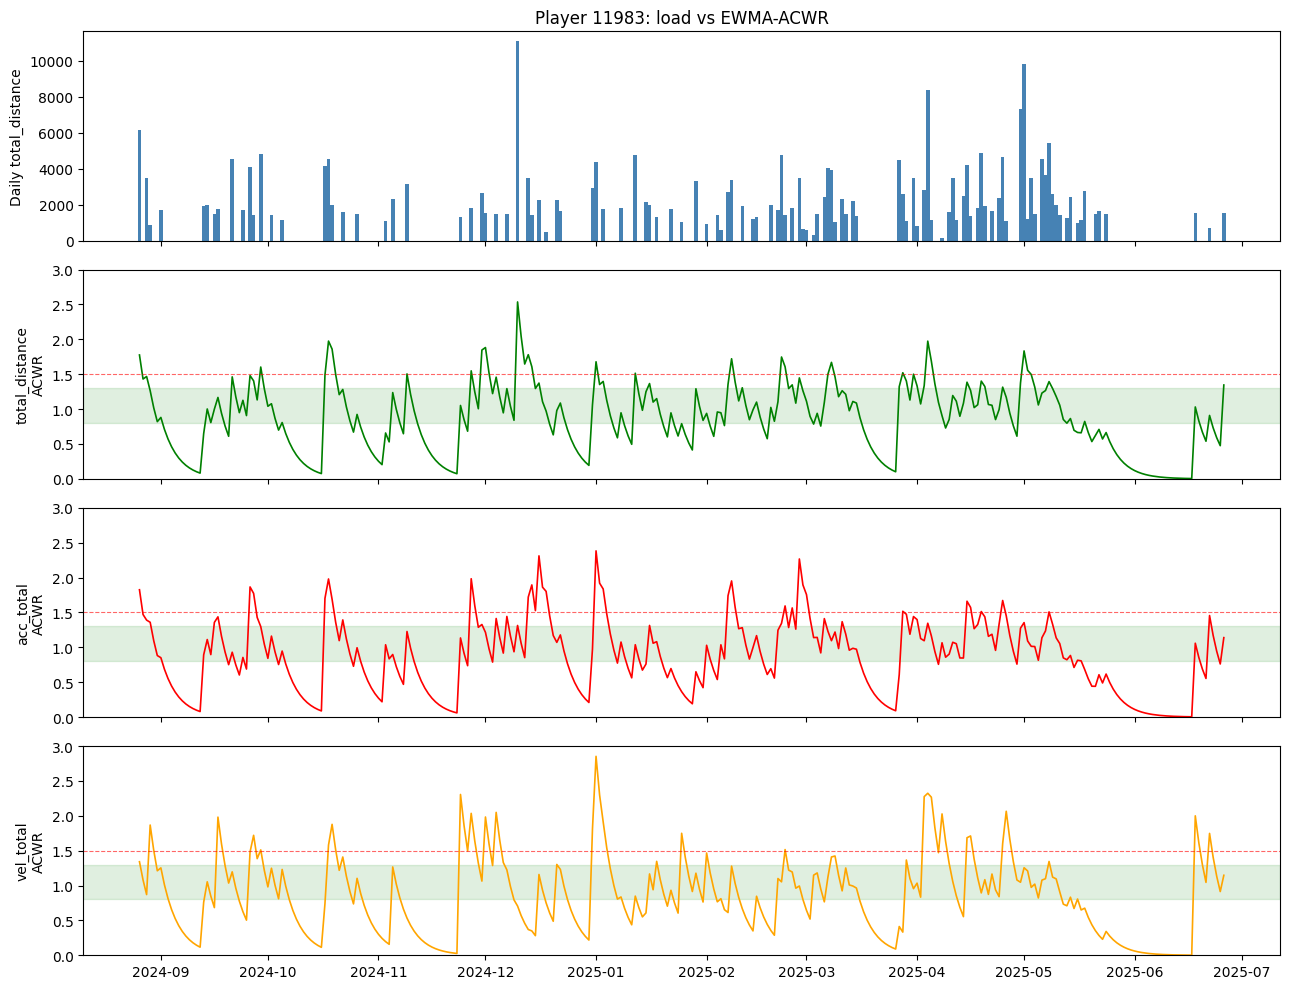

In [73]:
pid = full_grid[full_grid['is_modelable']].groupby('player_id', observed=True)['is_rest'].apply(
    lambda s: (s==0).mean()
).idxmax()

p = full_grid[(full_grid['player_id'] == pid) & (~full_grid['is_warmup'])].copy()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].bar(p['period_start_time'], p['total_distance'], color='steelblue', width=1.0)
axes[0].set_ylabel('Daily total_distance')
axes[0].set_title(f'Player {pid}: load vs EWMA-ACWR')

for ax, metric, color in zip(axes[1:], 
                              ['total_distance', 'acc_total', 'vel_total'],
                              ['green', 'red', 'orange']):
    ax.plot(p['period_start_time'], p[f'{metric}_acwr'], color=color, lw=1.2)
    ax.axhspan(0.8, 1.3, alpha=0.12, color='green')
    ax.axhline(1.5, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.set_ylabel(f'{metric}\nACWR')
    ax.set_ylim(0, 3)

plt.tight_layout()
plt.show()

In [74]:
full_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6310 entries, 0 to 6309
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   player_id                           6310 non-null   object        
 1   period_start_time                   6310 non-null   datetime64[ns]
 2   total_distance                      6310 non-null   float64       
 3   acc_total                           6310 non-null   float64       
 4   vel_total                           6310 non-null   float64       
 5   is_match                            6310 non-null   float64       
 6   n_periods                           6310 non-null   float64       
 7   exercise_types                      6310 non-null   object        
 8   position_name_en                    6310 non-null   object        
 9   height                              6310 non-null   float64       
 10  weight                  

In [75]:
# Add day_of_week columns if not already present
if 'day_of_week_name' not in full_grid.columns:
    full_grid['day_of_week'] = full_grid['period_start_time'].dt.dayofweek
    full_grid['day_of_week_name'] = full_grid['period_start_time'].dt.day_name()


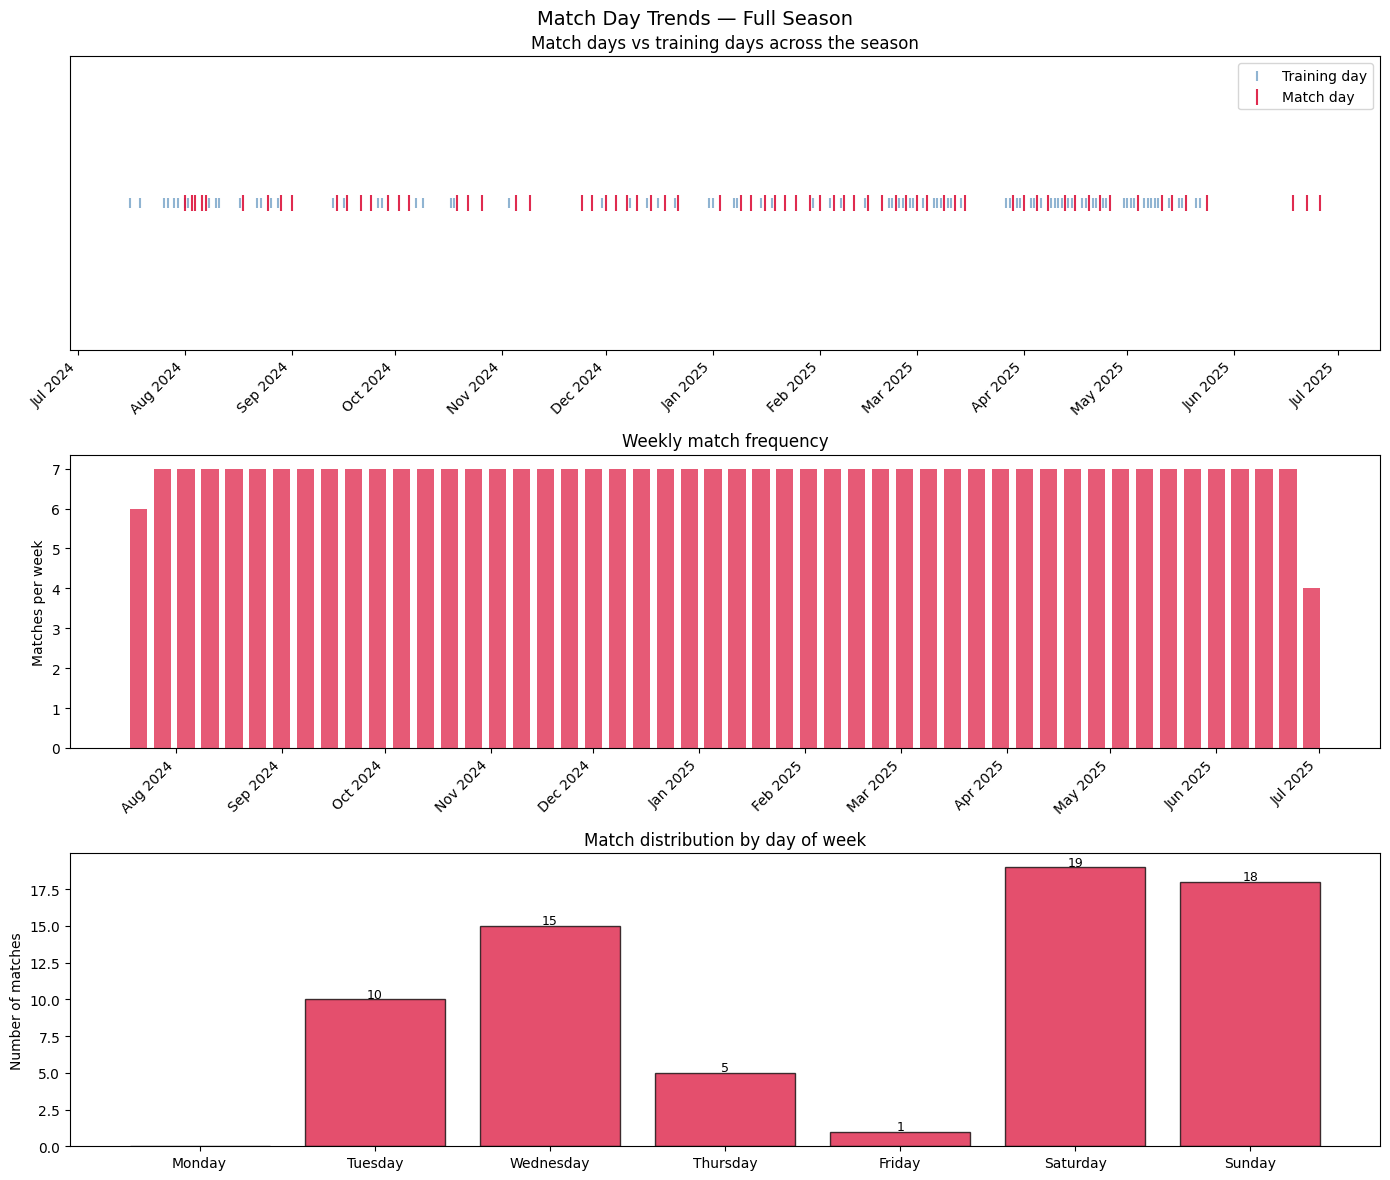

In [76]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Match Day Trends — Full Season", fontsize=14)

# Normalise is_match (mixed bool/int in the grid)
match_mask = full_grid['is_match'].astype(str).isin(['True', '1', '1.0'])

# ── 1. Timeline: match days vs rest/training days ──────────────────────────
match_days = full_grid[match_mask].drop_duplicates('period_start_time')['period_start_time']
non_match_active = full_grid[~match_mask & (full_grid['is_rest'] == 0)].drop_duplicates('period_start_time')['period_start_time']

axes[0].scatter(non_match_active, [1] * len(non_match_active),
                marker='|', color='steelblue', s=60, label='Training day', alpha=0.6)
axes[0].scatter(match_days, [1] * len(match_days),
                marker='|', color='crimson', s=120, label='Match day', alpha=0.9)
axes[0].set_yticks([])
axes[0].set_title("Match days vs training days across the season")
axes[0].legend(loc='upper right')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── 2. Weekly match count (rolling view of fixture density) ────────────────
daily_match_flag = (
    full_grid[match_mask]
    .drop_duplicates('period_start_time')
    .set_index('period_start_time')
    .reindex(pd.date_range(full_grid['period_start_time'].min(), full_grid['period_start_time'].max(), freq='D'))
    .assign(match=1)
    ['match']
    .fillna(0)
)
weekly = daily_match_flag.resample('W').sum()
axes[1].bar(weekly.index, weekly.values, width=5, color='crimson', alpha=0.7)
axes[1].set_ylabel('Matches per week')
axes[1].set_title("Weekly match frequency")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── 3. Day-of-week distribution of matches ─────────────────────────────────
dow_counts = (
    full_grid[match_mask]
    .drop_duplicates('period_start_time')
    ['day_of_week_name']
    .value_counts()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], fill_value=0)
)
axes[2].bar(dow_counts.index, dow_counts.values, color='crimson', alpha=0.75, edgecolor='black')
axes[2].set_ylabel('Number of matches')
axes[2].set_title("Match distribution by day of week")
for i, v in enumerate(dow_counts.values):
    if v > 0:
        axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


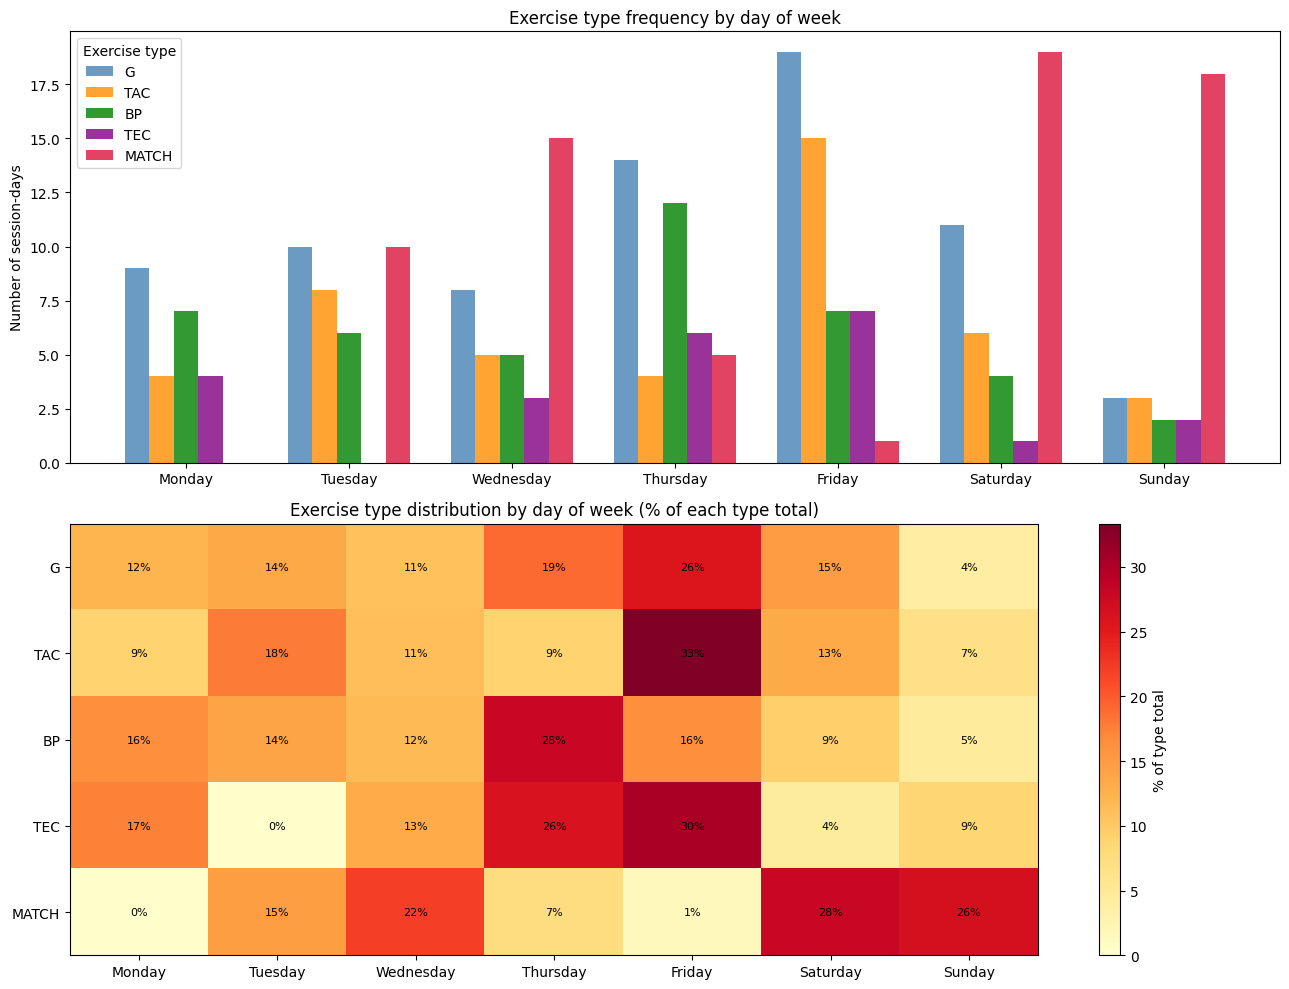

In [77]:
EXERCISE_TYPES = ['G', 'TAC', 'BP', 'TEC', 'MATCH']
DAYS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Explode frozensets into one row per (player_id, date, exercise_type)
active = full_grid[full_grid['is_rest'] == 0].copy()
exploded = (
    active
    .assign(exercise_type=active['exercise_types'].apply(list))
    .explode('exercise_type')
    [['period_start_time', 'day_of_week_name', 'exercise_type']]
    .drop_duplicates()  # one occurrence per date per type (not per player)
)

# Count occurrences per (day_of_week, exercise_type)
counts = (
    exploded.groupby(['day_of_week_name', 'exercise_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(DAYS)
    [EXERCISE_TYPES]
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Panel 1: grouped bar chart
x = np.arange(len(DAYS))
width = 0.15
colors = ['steelblue', 'darkorange', 'green', 'purple', 'crimson']

for i, (etype, color) in enumerate(zip(EXERCISE_TYPES, colors)):
    axes[0].bar(x + i * width, counts[etype], width=width,
                label=etype, color=color, alpha=0.8)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(DAYS)
axes[0].set_ylabel('Number of session-days')
axes[0].set_title('Exercise type frequency by day of week')
axes[0].legend(title='Exercise type')

# Panel 2: heatmap (normalised row-wise so each type sums to 100%)
norm_counts = counts.div(counts.sum(axis=0), axis=1) * 100

im = axes[1].imshow(norm_counts.T, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(len(DAYS)))
axes[1].set_xticklabels(DAYS)
axes[1].set_yticks(range(len(EXERCISE_TYPES)))
axes[1].set_yticklabels(EXERCISE_TYPES)
axes[1].set_title('Exercise type distribution by day of week (% of each type total)')

for i in range(len(EXERCISE_TYPES)):
    for j in range(len(DAYS)):
        axes[1].text(j, i, f'{norm_counts.iloc[j, i]:.0f}%',
                     ha='center', va='center', fontsize=8,
                     color='black' if norm_counts.iloc[j, i] < 60 else 'white')

plt.colorbar(im, ax=axes[1], label='% of type total')
plt.tight_layout()
plt.show()


## 6. Pipeline Output Summary

Final state of `full_grid` with all features computed. Confirms shape, modelable players, column inventory, and zero NaN values on the rows that matter for model training.

In [78]:
METRICS = ['total_distance', 'acc_total', 'vel_total']
modelable_ids = sorted(
    full_grid[full_grid['is_modelable']]['player_id'].unique().tolist(),
    key=str
)

# Categorise columns
id_cols        = ['player_id', 'period_start_time']
target_cols    = METRICS
acwr_cols      = [c for c in full_grid.columns
                  if any(t in c for t in ('_acute', '_chronic', '_acwr', 'is_warmup'))]
layoff_cols    = [c for c in ['days_since_last_active', 'is_returning_from_layoff',
                               'layoff_streak_length', 'cumulative_active_days_last_28',
                               'personal_layoff_excluding_team_off',]
                  if c in full_grid.columns]
static_cols    = [c for c in ['position_name_en', 'height', 'weight', 'date_of_birth',
                               'age', 'is_modelable', 'activity_rate']
                  if c in full_grid.columns]
calendar_cols  = [c for c in ['is_rest', 'rest_streak', 'is_match', 'n_periods',
                               'exercise_types', 'day_of_week', 'day_of_week_name','is_team_off_period']
                  if c in full_grid.columns]

print("=" * 58)
print("PIPELINE OUTPUT SUMMARY")
print("=" * 58)
print(f"Grid shape         : {full_grid.shape}")
print(f"Date range         : {full_grid['period_start_time'].min().date()} → {full_grid['period_start_time'].max().date()}")
print(f"Players total      : {full_grid['player_id'].nunique()}")
print(f"Modelable ({len(modelable_ids):2d})     : {modelable_ids}")
print()
print("Columns by category:")
print(f"  Identifiers      : {id_cols}")
print(f"  Load targets     : {target_cols}")
print(f"  ACWR features    : {acwr_cols}")
print(f"  Layoff features  : {layoff_cols}")
print(f"  Static metadata  : {static_cols}")
print(f"  Calendar         : {calendar_cols}")
print()

# NaN check on modelable active days for load metrics
active_modelable = full_grid[full_grid['is_modelable'] & (full_grid['is_rest'] == 0)]
nan_counts = active_modelable[METRICS].isna().sum()
print("NaN in load metrics (modelable active days):")
for col, n in nan_counts.items():
    print(f"  {col}: {n}")
assert nan_counts.sum() == 0, "Unexpected NaN in load metrics"
print("  → All zero ✓")
print()

# Prepare for Parquet: serialise non-primitive types
fg_save = full_grid.copy()
fg_save['exercise_types'] = fg_save['exercise_types'].apply(
    lambda s: '+'.join(sorted(s)) if isinstance(s, frozenset) and s else ''
)
fg_save['is_match'] = fg_save['is_match'].fillna(0)
# player_id may be category — cast to str for broadest parquet compatibility
fg_save['player_id'] = fg_save['player_id'].astype(str)

out_path = 'processed_grid.parquet'
try:
    import pyarrow  # noqa: F401
    fg_save.to_parquet(out_path, index=False)
    print(f"Saved → {out_path}  (pyarrow, {len(fg_save):,} rows × {fg_save.shape[1]} cols)")
except ImportError:
    import pickle
    out_path = 'processed_grid.pkl'
    with open(out_path, 'wb') as fh:
        pickle.dump(full_grid, fh)
    print(f"Saved → {out_path}  (pickle fallback — install pyarrow for parquet)")

PIPELINE OUTPUT SUMMARY
Grid shape         : (6310, 35)
Date range         : 2024-07-16 → 2025-06-26
Players total      : 28
Modelable (18)     : [11983, 18236, 21190, 21206, 28635, 30026, 31083, 37191, 39471, 48463, 59915, 62110, 64878, 70334, 93025, 93988, 94884, 95293]

Columns by category:
  Identifiers      : ['player_id', 'period_start_time']
  Load targets     : ['total_distance', 'acc_total', 'vel_total']
  ACWR features    : ['total_distance_acute', 'total_distance_chronic', 'total_distance_acwr', 'acc_total_acute', 'acc_total_chronic', 'acc_total_acwr', 'vel_total_acute', 'vel_total_chronic', 'vel_total_acwr', 'is_warmup']
  Layoff features  : ['days_since_last_active', 'is_returning_from_layoff', 'layoff_streak_length', 'cumulative_active_days_last_28', 'personal_layoff_excluding_team_off']
  Static metadata  : ['position_name_en', 'height', 'weight', 'date_of_birth', 'age', 'is_modelable', 'activity_rate']
  Calendar         : ['is_rest', 'rest_streak', 'is_match', 'n_perio

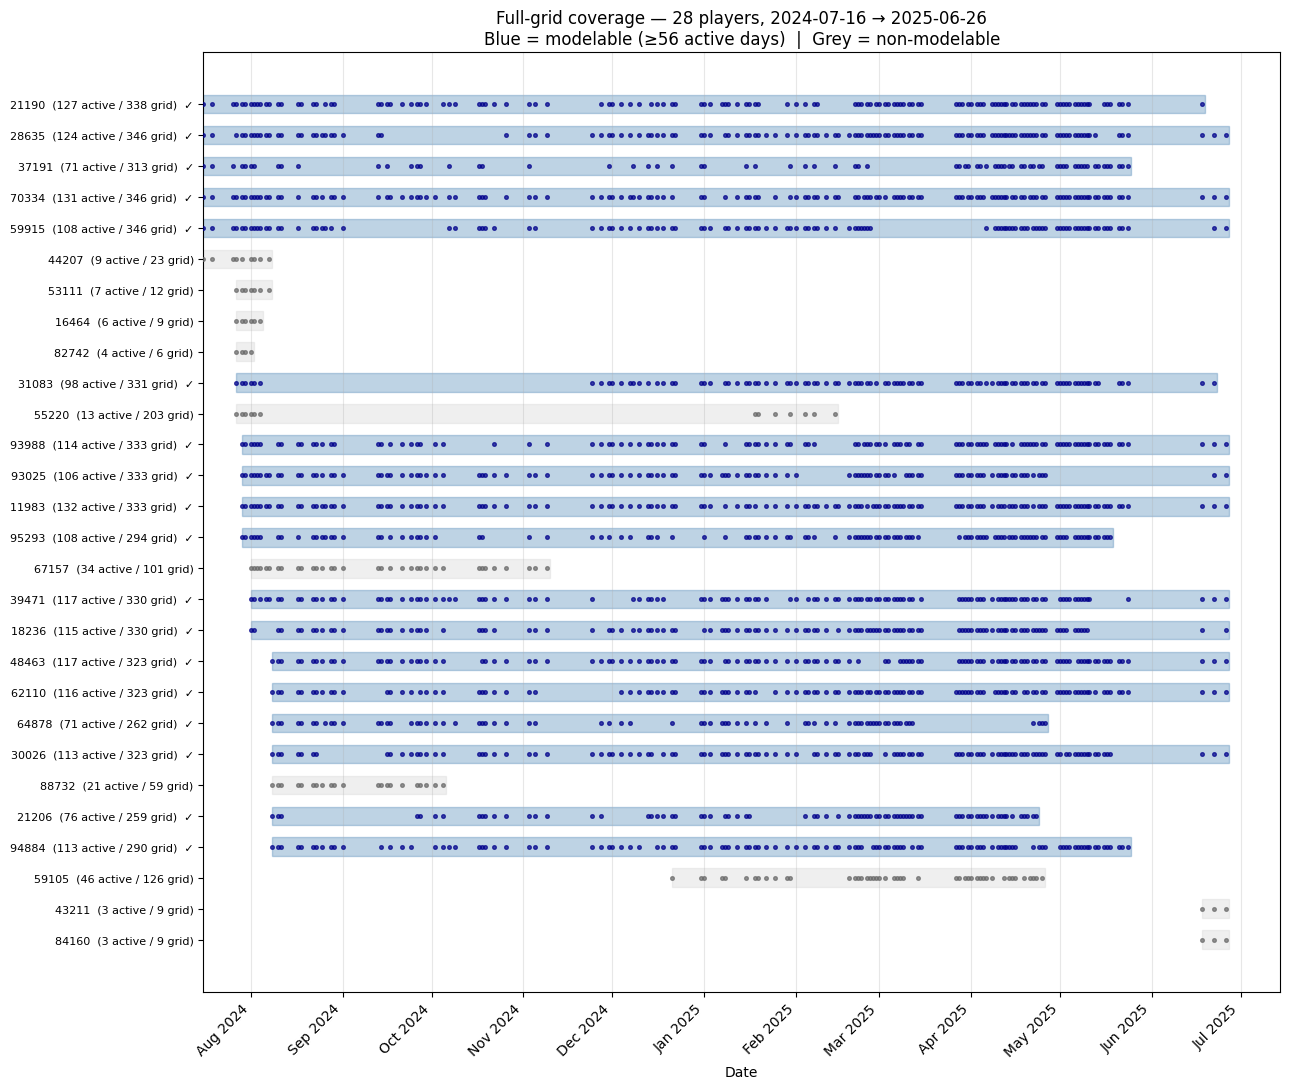

    player_id first_date  last_date  active_days  grid_days  is_modelable
0       21190 2024-07-16 2025-06-18          127        338          True
1       28635 2024-07-16 2025-06-26          124        346          True
2       37191 2024-07-16 2025-05-24           71        313          True
3       70334 2024-07-16 2025-06-26          131        346          True
4       59915 2024-07-16 2025-06-26          108        346          True
5       44207 2024-07-16 2024-08-07            9         23         False
6       53111 2024-07-27 2024-08-07            7         12         False
7       16464 2024-07-27 2024-08-04            6          9         False
8       82742 2024-07-27 2024-08-01            4          6         False
9       31083 2024-07-27 2025-06-22           98        331          True
10      55220 2024-07-27 2025-02-14           13        203         False
11      93988 2024-07-29 2025-06-26          114        333          True
12      93025 2024-07-29 2025-06-26   

In [79]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_grid_coverage(full_grid, figsize=(13, 11)):
    player_col = 'player_id'
    date_col   = 'period_start_time'

    summary = (
        full_grid.groupby(player_col, observed=True)
        .agg(
            first_date=(date_col, 'min'),
            last_date=(date_col, 'max'),
            active_days=('is_rest', lambda s: (s == 0).sum()),
            grid_days=(date_col, 'count'),
            is_modelable=('is_modelable', 'first'),
        )
        .sort_values('first_date')
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=figsize)

    for i, row in summary.iterrows():
        # Bar colour: green = modelable, grey = non-modelable
        colour = 'steelblue' if row['is_modelable'] else 'lightgrey'
        ax.barh(y=i,
                width=(row['last_date'] - row['first_date']).days + 1,
                left=row['first_date'],
                height=0.6,
                color=colour, alpha=0.35, edgecolor=colour)

        # Active days as dots
        active_dates = full_grid.loc[
            (full_grid[player_col] == row[player_col]) & (full_grid['is_rest'] == 0),
            date_col
        ]
        dot_colour = 'darkblue' if row['is_modelable'] else 'dimgrey'
        ax.scatter(active_dates, [i] * len(active_dates),
                   s=7, color=dot_colour, alpha=0.7, zorder=3)

    # Y-axis labels
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels([
        f"{row[player_col]}  ({row['active_days']} active / {row['grid_days']} grid)"
        + ("  ✓" if row['is_modelable'] else "")
        for _, row in summary.iterrows()
    ], fontsize=8)

    ax.set_xlabel('Date')
    ax.set_title(
        f"Full-grid coverage — {len(summary)} players, "
        f"{full_grid[date_col].min().date()} → {full_grid[date_col].max().date()}\n"
        f"Blue = modelable (≥56 active days)  |  Grey = non-modelable"
    )
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(True, axis='x', alpha=0.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return summary

summary = plot_grid_coverage(full_grid)
print(summary[['player_id','first_date','last_date','active_days','grid_days','is_modelable']])


---
# Part 2: Feature Engineering for XGBoost ACWR Forecasting

67 features across 9 categories (A–I) built on top of the processed grid from Part 1.
`full_grid` is already in memory — no parquet round-trip needed.

In [80]:
# full_grid already built above — use it directly
df = full_grid.copy()

# Normalise is_match to int (may be bool/int mix in pipeline output)
df['is_match'] = df['is_match'].apply(lambda x: 1 if str(x) in ['True', '1', '1.0'] else 0)

# exercise_types is already frozenset from aggregate_to_daily; player_id already category
df = df.sort_values(['player_id', 'period_start_time']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"\nDtype summary:")
print(df.dtypes.value_counts().to_string())
print(f"\nDate range : {df['period_start_time'].min().date()} \u2192 {df['period_start_time'].max().date()}")
print(f"Players    : {df['player_id'].nunique()}")
print(f"Modelable  : {df[df['is_modelable']]['player_id'].nunique()}")
print(f"\nSample exercise_types (first 5 active days):")
print(df[df['is_rest'] == 0]['exercise_types'].head().to_string())

Shape: (6310, 35)

Dtype summary:
float64           17
int64              6
bool               5
object             4
datetime64[ns]     2
int32              1

Date range : 2024-07-16 → 2025-06-26
Players    : 28
Modelable  : 18

Sample exercise_types (first 5 active days):
0           (BP, TAC, G)
1           (BP, TAC, G)
3    (MATCH, BP, TEC, G)
4           (BP, TAC, G)
5                (MATCH)


## 7. Feature Engineering

67 features across 9 categories:

| # | Category | Features |
|---|---|---|
| A | Lag features | 15 |
| B | ACWR & EWMA state | 10 |
| C | Rolling statistics | 12 |
| D | Match context | 5 |
| E | Proposed training type (KEY) | 7 |
| F | Layoff features (pre-built) | 6 |
| G | Calendar | 4 |
| H | Player static | 5 |
| I | Interactions | 3 |

All groupby operations use `observed=True`. All rolling features use `.shift(1).rolling()` to exclude today's value from the window — no leakage.

### 2.A Lag Features (15 features)

Lags of all three metrics at t−1, t−2, t−3, t−7, t−14. Cross-metric lags are included because distance, acceleration, and HSR load tend to co-vary — yesterday's total_distance is informative when predicting today's acc_total.

In [81]:
METRICS = ['total_distance', 'acc_total', 'vel_total']
LAGS    = [1, 2, 3, 7, 14]

for metric in METRICS:
    for lag in LAGS:
        df[f'{metric}_lag_{lag}'] = (
            df.groupby('player_id', observed=True)[metric].shift(lag)
        )

lag_cols = [f'{m}_lag_{l}' for m in METRICS for l in LAGS]
print(f"Lag features added: {len(lag_cols)}")
print(lag_cols)

# Verification: lag_7 at row i should equal the raw value at row i-7 for same player
pid   = df['player_id'].cat.categories[0]
p     = df[df['player_id'] == pid].reset_index(drop=True)
row   = 14  # first row with a valid lag_14
check = p.loc[row, 'total_distance_lag_7']
truth = p.loc[row - 7, 'total_distance']
print(f"\nVerification — player {pid}, row {row}:")
print(f"  total_distance_lag_7 = {check:.4f}")
print(f"  total_distance @ row {row-7} = {truth:.4f}")
print(f"  Match: {abs(check - truth) < 1e-6}")

Lag features added: 15
['total_distance_lag_1', 'total_distance_lag_2', 'total_distance_lag_3', 'total_distance_lag_7', 'total_distance_lag_14', 'acc_total_lag_1', 'acc_total_lag_2', 'acc_total_lag_3', 'acc_total_lag_7', 'acc_total_lag_14', 'vel_total_lag_1', 'vel_total_lag_2', 'vel_total_lag_3', 'vel_total_lag_7', 'vel_total_lag_14']


AttributeError: Can only use .cat accessor with a 'category' dtype

### 2.B ACWR & EWMA State (10 features)

The nine ACWR columns (`{metric}_acute`, `{metric}_chronic`, `{metric}_acwr`) were computed by the pipeline. We add `max_acwr` — the row-wise maximum across the three ACWR values — as a single injury-risk summary signal.

In [ ]:
ACWR_COLS = [f'{m}_{s}' for m in METRICS for s in ['acute', 'chronic', 'acwr']]
missing = [c for c in ACWR_COLS if c not in df.columns]
assert not missing, f"Missing ACWR columns: {missing}"
print(f"ACWR columns confirmed ({len(ACWR_COLS)}): {ACWR_COLS}")

# max_acwr: row-wise max of the three _acwr columns, NaN if all three are NaN (warmup)
acwr_only = [f'{m}_acwr' for m in METRICS]
df['max_acwr'] = df[acwr_only].max(axis=1, skipna=True)

# Distribution on active post-warmup days
post_wu = df[(df['is_rest'] == 0) & (~df['is_warmup'])]
print(f"\nmax_acwr quantiles on active post-warmup days ({len(post_wu)} rows):")
print(post_wu['max_acwr'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(3).to_string())

### 2.C Rolling Statistics (12 features)

Unweighted rolling windows contrasting with the EWMA-based acute/chronic columns. Four statistics per metric: 7-day mean, 28-day mean, 7-day std, 7-day max.

**Leakage guard:** all windows use `.shift(1).rolling()` so the feature at day t uses only days t−1 … t−k, never today.

In [ ]:
for metric in METRICS:
    base = df.groupby('player_id', observed=True)[metric]
    # shift(1) excludes today before rolling — prevents look-ahead leakage
    df[f'{metric}_rollmean_7']  = base.transform(lambda s: s.shift(1).rolling(7,  min_periods=1).mean())
    df[f'{metric}_rollmean_28'] = base.transform(lambda s: s.shift(1).rolling(28, min_periods=1).mean())
    df[f'{metric}_rollstd_7']   = base.transform(lambda s: s.shift(1).rolling(7,  min_periods=2).std())
    df[f'{metric}_rollmax_7']   = base.transform(lambda s: s.shift(1).rolling(7,  min_periods=1).max())

roll_cols = [f'{m}_{s}' for m in METRICS for s in ['rollmean_7','rollmean_28','rollstd_7','rollmax_7']]
print(f"Rolling features added: {len(roll_cols)}")

# Verification: rollmean_7 at row i = mean of rows i-7 … i-1
pid = df['player_id'].cat.categories[0]
p   = df[df['player_id'] == pid].reset_index(drop=True)
row = 20
manual   = p.loc[row - 7 : row - 1, 'total_distance'].mean()
computed = p.loc[row, 'total_distance_rollmean_7']
print(f"\nVerification rollmean_7 at row {row} for player {pid}:")
print(f"  Manual mean of rows {row-7}–{row-1}: {manual:.4f}")
print(f"  Computed: {computed:.4f}")
print(f"  Match: {abs(manual - computed) < 1e-6}")

### 2.D Match Context Features (5 features)

Match scheduling creates a predictable load cycle: high load on match day, reduced load the day after, tactical buildup in the days before. These features capture where each row sits in that cycle.

In [ ]:
# days_since_last_match: forward-fill the last match date within each player
def _days_since_last_match(g):
    last_match = g['period_start_time'].where(g['is_match'] == 1).ffill()
    return (g['period_start_time'] - last_match).dt.days

df['days_since_last_match'] = (
    df.groupby('player_id', observed=True, group_keys=False)
    .apply(_days_since_last_match)
)

# days_until_next_match: backward-fill the next match date
def _days_until_next_match(g):
    next_match = g['period_start_time'].where(g['is_match'] == 1).bfill()
    return (next_match - g['period_start_time']).dt.days

df['days_until_next_match'] = (
    df.groupby('player_id', observed=True, group_keys=False)
    .apply(_days_until_next_match)
)

# Rolling match counts — shift(1) to exclude today
df['matches_last_7d'] = (
    df.groupby('player_id', observed=True)['is_match']
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
    .fillna(0).astype(int)
)
df['matches_last_28d'] = (
    df.groupby('player_id', observed=True)['is_match']
    .transform(lambda s: s.shift(1).rolling(28, min_periods=1).sum())
    .fillna(0).astype(int)
)

df['is_match_today'] = df['is_match'].astype(bool)

# Report distributions on non-match active days
active_nm = df[(df['is_rest'] == 0) & (df['is_match'] == 0)]
print(f"Match context features built. Non-match active rows: {len(active_nm)}")
print(f"\ndays_since_last_match:")
print(active_nm['days_since_last_match'].describe().round(1).to_string())
print(f"\ndays_until_next_match:")
print(active_nm['days_until_next_match'].describe().round(1).to_string())

### 2.E Proposed Training Type for Day t+1 (KEY — 7 features)

This is the most important feature category. At inference time, the coaching staff provides the planned session composition for tomorrow. The model uses that plan to predict tomorrow's workload.

At training time, tomorrow's `exercise_types` is already known (we're looking at historical data), so we shift the column backward by one day to align it with today's feature row. No leakage — we are genuinely asking "given what we know will happen tomorrow, what load will this player produce?" 

In [ ]:
# Shift exercise_types, is_rest, is_match by -1 to get NEXT day's values
next_exercise    = df.groupby('player_id', observed=True)['exercise_types'].shift(-1)
next_is_rest_raw = df.groupby('player_id', observed=True)['is_rest'].shift(-1)
next_is_match_raw = df.groupby('player_id', observed=True)['is_match'].shift(-1)

for t in ['G', 'TAC', 'BP', 'TEC']:
    df[f'next_has_{t}'] = next_exercise.apply(
        lambda s: t in s if isinstance(s, frozenset) else False
    )

df['next_is_match'] = next_is_match_raw.fillna(0).astype(bool)
df['next_is_rest']  = next_is_rest_raw.fillna(1).astype(bool)   # last row has no tomorrow → treat as rest
df['next_n_types']  = next_exercise.apply(lambda s: len(s) if isinstance(s, frozenset) else 0)

print("Next-day training type features built.")
print(f"\nnext_is_rest value counts:\n{df['next_is_rest'].value_counts().to_string()}")

# Critical checks
rest_rows  = df[df['next_is_rest']]
match_rows = df[df['next_is_match']]

print(f"\nFor next_is_rest=True rows ({len(rest_rows)}):")
for t in ['G', 'TAC', 'BP', 'TEC']:
    n = rest_rows[f'next_has_{t}'].sum()
    print(f"  next_has_{t}=True: {n}  (expected 0)")
print(f"  next_n_types > 0:  {(rest_rows['next_n_types'] > 0).sum()}  (expected 0)")

print(f"\nFor next_is_match=True rows ({len(match_rows)}):")
print(f"  next_n_types == 1: {(match_rows['next_n_types'] == 1).sum()}  (expected {len(match_rows)})")
print(f"  next_has_G=True:   {match_rows['next_has_G'].sum()}  (expected 0)")

### 2.F Layoff Features (already built — 6 features)

These columns were computed in the data pipeline notebook and are present in `processed_grid.parquet`. No recomputation needed.

In [ ]:
LAYOFF_COLS = [
    'days_since_last_active', 'is_returning_from_layoff', 'layoff_streak_length',
    'cumulative_active_days_last_28', 'personal_layoff_excluding_team_off', 'is_team_off_period'
]
missing = [c for c in LAYOFF_COLS if c not in df.columns]
assert not missing, f"Missing layoff columns: {missing}"
print(f"All 6 layoff features confirmed.\n")

for col in LAYOFF_COLS:
    s = df[col]
    if set(s.dropna().unique()).issubset({0, 1, True, False}):
        vc = s.astype(int).value_counts().sort_index()
        print(f"{col}: {vc.to_dict()}")
    else:
        print(f"{col}: min={s.min():.1f}  median={s.median():.1f}  "
              f"max={s.max():.1f}  NaN={s.isna().sum()}")

### 2.G Calendar Features (4 features)

Day-of-week, weekend flag, month, and days-into-season. The season anchor is the earliest date in the dataset.

In [ ]:
assert 'day_of_week' in df.columns, "day_of_week missing — run data pipeline first"
print("day_of_week confirmed (0=Mon … 6=Sun)")

df['is_weekend']       = df['day_of_week'].isin([5, 6]).astype(int)
df['month']            = df['period_start_time'].dt.month
season_start           = df['period_start_time'].min()
df['days_into_season'] = (df['period_start_time'] - season_start).dt.days

print(f"\nis_weekend:       {df['is_weekend'].value_counts().sort_index().to_dict()}")
print(f"month range:      {df['month'].min()} – {df['month'].max()}")
print(f"days_into_season: 0 – {df['days_into_season'].max()}")

### 2.H Player Static Features (5 features)

Position, age, height, weight, and player identity. XGBoost can use integer-coded categoricals directly (with `enable_categorical=True`), so we encode now and retain the original strings for interpretability.

In [ ]:
# Position → int code
df['position_name_en'] = df['position_name_en'].astype('category')
df['position_code']    = df['position_name_en'].cat.codes

# player_id is already category
df['player_code'] = df['player_id'].cat.codes

# Print mappings for later interpretation
pos_map = (
    df[['position_name_en', 'position_code']]
    .drop_duplicates().sort_values('position_code')
    .set_index('position_code')['position_name_en'].to_dict()
)
print("position_code → position_name_en:")
for k, v in pos_map.items():
    print(f"  {k}: {v}")

player_map = (
    df[['player_id', 'player_code']]
    .drop_duplicates().sort_values('player_code')
    .assign(player_id=lambda d: d['player_id'].astype(str))
    .set_index('player_code')['player_id'].to_dict()
)
print(f"\nplayer_code → player_id (first 5 of {len(player_map)}):")
for k in sorted(player_map)[:5]:
    print(f"  {k}: {player_map[k]}")

### 2.I Interaction Features (3 features)

- **next_intensity_score**: weighted sum of tomorrow's exercise type flags — a single numerical proxy for how demanding tomorrow's session is expected to be.
- **current_load_vs_chronic**: today's distance relative to the 28-day EWMA baseline — captures whether the player is in a high- or low-load phase.
- **is_post_match_day**: first day after a match, when recovery vs. re-loading decisions are most consequential.

In [ ]:
# Weights reflect physiological demand: match > game-based > tactical > technical/set-piece
df['next_intensity_score'] = (
    10 * df['next_is_match'].astype(int) +
     4 * df['next_has_G'].astype(int)   +
     2 * df['next_has_TAC'].astype(int) +
     1 * df['next_has_TEC'].astype(int) +
     1 * df['next_has_BP'].astype(int)
)

# Ratio of today's distance to chronic baseline (NaN during warmup / before first session)
df['current_load_vs_chronic'] = np.where(
    df['total_distance_chronic'] > 0,
    df['total_distance'] / df['total_distance_chronic'],
    np.nan
)

# Binary: is this the first active day after a match?
df['is_post_match_day'] = (df['days_since_last_match'] == 1).astype(int)

print("Interaction features built.")
print(f"\nnext_intensity_score value counts:")
print(df['next_intensity_score'].value_counts().sort_index().to_string())
print(f"\ncurrent_load_vs_chronic: median={df['current_load_vs_chronic'].median():.3f}  "
      f"NaN={df['current_load_vs_chronic'].isna().sum()}")
print(f"\nis_post_match_day: {df['is_post_match_day'].value_counts().sort_index().to_dict()}")

## 8. Construct Target Columns

The target for each model is the **next day's raw workload**. We shift each metric backward by one day within each player's timeline. Each player's last row will have `NaN` targets — those rows are excluded from training but retained in the feature matrix for inference.

In [ ]:
for metric in METRICS:
    df[f'target_{metric}'] = df.groupby('player_id', observed=True)[metric].shift(-1)

target_cols = [f'target_{m}' for m in METRICS]
valid_mask  = df[target_cols].notna().all(axis=1)

print(f"Rows with valid targets (has a tomorrow): {valid_mask.sum()}")
print(f"Rows with NaN targets  (last day per player): {(~valid_mask).sum()}")

# Verify: target in row i == load in row i+1 for same player
pid = df['player_id'].cat.categories[0]
p   = df[df['player_id'] == pid][['period_start_time', 'total_distance', 'target_total_distance']].head(4)
print(f"\nVerification — player {pid} (target_total_distance should equal next row's total_distance):")
print(p.to_string())

## 9. Final Feature Matrix

Assemble explicit feature lists by category, assert the total is 67, then build `modeling_df` containing only the columns needed downstream.

In [ ]:
LAG_FEATURES       = [f'{m}_lag_{l}' for m in METRICS for l in LAGS]
ACWR_FEATURES      = [f'{m}_{s}' for m in METRICS for s in ['acute','chronic','acwr']] + ['max_acwr']
ROLLING_FEATURES   = [f'{m}_{s}' for m in METRICS
                       for s in ['rollmean_7','rollmean_28','rollstd_7','rollmax_7']]
MATCH_FEATURES     = ['days_since_last_match','days_until_next_match',
                       'matches_last_7d','matches_last_28d','is_match_today']
NEXT_DAY_FEATURES  = ['next_has_G','next_has_TAC','next_has_BP','next_has_TEC',
                       'next_is_match','next_is_rest','next_n_types']
LAYOFF_FEATURES    = LAYOFF_COLS   # defined in Cell 17
CALENDAR_FEATURES  = ['day_of_week','is_weekend','month','days_into_season']
STATIC_FEATURES    = ['position_code','player_code','age','height','weight']
INTERACTION_FEATURES = ['next_intensity_score','current_load_vs_chronic','is_post_match_day']

ALL_FEATURES = (LAG_FEATURES + ACWR_FEATURES + ROLLING_FEATURES + MATCH_FEATURES +
                NEXT_DAY_FEATURES + LAYOFF_FEATURES + CALENDAR_FEATURES +
                STATIC_FEATURES + INTERACTION_FEATURES)

assert len(ALL_FEATURES) == 67, f"Expected 67 features, got {len(ALL_FEATURES)}"

print("Feature count by category:")
for label, lst in [
    ('A. Lags',               LAG_FEATURES),
    ('B. ACWR state',         ACWR_FEATURES),
    ('C. Rolling stats',      ROLLING_FEATURES),
    ('D. Match context',      MATCH_FEATURES),
    ('E. Next-day training',  NEXT_DAY_FEATURES),
    ('F. Layoff',             LAYOFF_FEATURES),
    ('G. Calendar',           CALENDAR_FEATURES),
    ('H. Static',             STATIC_FEATURES),
    ('I. Interactions',       INTERACTION_FEATURES),
]:
    print(f"  {label:25s}: {len(lst):2d}")
print(f"  {'TOTAL':25s}: {len(ALL_FEATURES):2d}  ✓")

TARGETS = [f'target_{m}' for m in METRICS]

keep_cols    = ['player_id','period_start_time','is_modelable','is_warmup'] + ALL_FEATURES + TARGETS
# Guard: confirm every expected column exists before slicing
missing_cols = [c for c in keep_cols if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

modeling_df = df[keep_cols].copy()
print(f"\nmodeling_df shape: {modeling_df.shape}")

## 10. Filter Training Rows

Three filters define a usable training row:
1. **`is_modelable == True`** — player has ≥56 active days (28 warmup + 28 post-warmup minimum)
2. **`is_warmup == False`** — chronic EWMA has converged; ACWR features are meaningful
3. **Targets not NaN** — each player's last day has no t+1, so cannot be used as a training example

NaN in *feature* columns (early lag/roll values) are left intact — XGBoost handles them natively via its built-in missing-value split logic.

In [ ]:
pre_filter = len(modeling_df)

training_df = modeling_df[
    (modeling_df['is_modelable'] == True) &
    (~modeling_df['is_warmup']) &
    modeling_df[TARGETS].notna().all(axis=1)
].copy()

print(f"Rows before filtering : {pre_filter:,}")
print(f"Rows after filtering  : {len(training_df):,}")
print(f"Dropped               : {pre_filter - len(training_df):,}")

print(f"\nPer-player row counts in training_df:")
print(training_df.groupby('player_id', observed=True).size()
      .sort_values(ascending=False).to_string())

nan_counts = training_df[ALL_FEATURES].isna().sum().sort_values(ascending=False)
nonzero    = nan_counts[nan_counts > 0]
print(f"\nFeatures with NaN in training_df ({len(nonzero)} of {len(ALL_FEATURES)}):")
if len(nonzero):
    print(nonzero.to_string())
else:
    print("  None")
print("\n(XGBoost handles NaN natively — no imputation needed)")

## 11. Walk-Forward Validation Setup

Expanding-window validation with a 15-day step. The first training window covers the initial 6 months of data; each subsequent fold appends another 15 days to the training set and tests on the next 15-day block. This mirrors real deployment: the model always trains on everything seen so far and forecasts forward.

In [ ]:
def make_walk_forward_folds(df, initial_train_months=6, step_days=15, min_test_days=15):
    """
    Expanding-window walk-forward validation.

    Parameters
    ----------
    df                  : DataFrame with a 'period_start_time' column.
    initial_train_months: size of first training window.
    step_days           : how far each fold advances (train and test window size).
    min_test_days       : stop when fewer than this many rows remain for testing.

    Returns
    -------
    list of (train_indices, test_indices) Index objects.
    """
    folds    = []
    min_date = df['period_start_time'].min()
    max_date = df['period_start_time'].max()
    step     = pd.Timedelta(days=step_days)

    train_end = min_date + pd.DateOffset(months=initial_train_months)

    while True:
        test_end  = train_end + step
        test_idx  = df.index[(df['period_start_time'] > train_end) & (df['period_start_time'] <= test_end)]

        if len(test_idx) < min_test_days:
            break

        train_idx = df.index[df['period_start_time'] <= train_end]
        folds.append((train_idx, test_idx))
        train_end += step

    return folds


folds = make_walk_forward_folds(training_df)
print(f"Walk-forward folds defined: {len(folds)}\n")

for i, (tr, te) in enumerate(folds):
    tr_d = training_df.loc[tr, 'period_start_time']
    te_d = training_df.loc[te, 'period_start_time']
    print(f"Fold {i+1:2d}: "
          f"train {tr_d.min().date()} → {tr_d.max().date()} ({len(tr):4d} rows) | "
          f"test  {te_d.min().date()} → {te_d.max().date()} ({len(te):4d} rows)")

## 12. Save Feature Matrix

In [ ]:
# ── Extra columns needed for inference-time feature reconstruction ─────────────
# Raw load metrics: today's actuals become lag_1 when forecasting tomorrow
# State flags + exercise_types: needed to re-enter the feature pipeline at inference
EXTRA_COLS = ['total_distance', 'acc_total', 'vel_total',
              'is_match', 'is_rest', 'exercise_types']

extra = df[['player_id', 'period_start_time'] + EXTRA_COLS].copy()

# exercise_types: frozenset → '+'-joined string (Parquet-safe, matches processed_grid convention)
extra['exercise_types'] = extra['exercise_types'].apply(
    lambda s: '+'.join(sorted(s)) if isinstance(s, frozenset) else (s if isinstance(s, str) else ''))

# is_match: normalise mixed bool/int/NaN → int
extra['is_match'] = (
    extra['is_match'].fillna(0)
    .apply(lambda x: 1 if str(x) in ['True', '1', '1.0'] else 0)
    .astype(int)
)

# ── Merge extra columns onto modeling_df ───────────────────────────────────────
save_df = modeling_df.copy()
save_df = save_df.merge(extra, on=['player_id', 'period_start_time'], how='left')

# ── Dtype fixes ────────────────────────────────────────────────────────────────
save_df['player_id'] = save_df['player_id'].astype(str)

# is_modelable → bool (preserve semantic clarity for modeling notebook)
save_df['is_modelable'] = save_df['is_modelable'].astype(bool)

# All other bool columns → int (avoids pyarrow mixed-type issues)
for col in save_df.select_dtypes(include='bool').columns:
    if col == 'is_modelable':
        continue
    save_df[col] = save_df[col].astype(int)

# Categorical → str
for col in save_df.select_dtypes(include='category').columns:
    save_df[col] = save_df[col].astype(str)

# ── Save features.parquet ──────────────────────────────────────────────────────
save_df.to_parquet('features.parquet', index=False)
sz_parquet = Path('features.parquet').stat().st_size / 1024
print(f"Saved: features.parquet  ({len(save_df):,} rows × {save_df.shape[1]} cols, {sz_parquet:.1f} KB)")

extra_beyond_features = [
    c for c in save_df.columns
    if c not in ALL_FEATURES + TARGETS + ['player_id', 'period_start_time', 'is_modelable', 'is_warmup']
]
print(f"\nExtra columns beyond 67 features + targets (for inference):")
for c in extra_beyond_features:
    print(f"  {c}  [{save_df[c].dtype}]")

# ── Save feature_lists.json ────────────────────────────────────────────────────
feature_lists = {
    'ALL_FEATURES':         ALL_FEATURES,
    'TARGETS':              TARGETS,
    'LAG_FEATURES':         LAG_FEATURES,
    'ACWR_FEATURES':        ACWR_FEATURES,
    'ROLLING_FEATURES':     ROLLING_FEATURES,
    'MATCH_FEATURES':       MATCH_FEATURES,
    'NEXT_DAY_FEATURES':    NEXT_DAY_FEATURES,
    'LAYOFF_FEATURES':      list(LAYOFF_FEATURES),
    'CALENDAR_FEATURES':    CALENDAR_FEATURES,
    'STATIC_FEATURES':      STATIC_FEATURES,
    'INTERACTION_FEATURES': INTERACTION_FEATURES,
}
json_path = Path('feature_lists.json')
with open(json_path, 'w') as fh:
    json.dump(feature_lists, fh, indent=2)
sz_json = json_path.stat().st_size
print(f"\nSaved: feature_lists.json ({sz_json:,} bytes)")
print(f"Keys  : {list(feature_lists.keys())}")
print(f"ALL_FEATURES count: {len(feature_lists['ALL_FEATURES'])}  ✓")

## 13. Summary

| Item | Value |
|---|---|
| Total features | **67** |
| Total target columns | **3** (one per load metric) |
| Feature categories | 9 (A–I) |
| Lag features | 15 (3 metrics × 5 lags) |
| ACWR / EWMA state | 10 (9 pipeline cols + max_acwr) |
| Rolling stats | 12 (3 metrics × 4 windows) |
| Match context | 5 |
| Proposed training type | 7 (KEY — coach input at inference) |
| Layoff features | 6 (pre-built in pipeline) |
| Calendar | 4 |
| Player static | 5 |
| Interaction | 3 |
| Files saved | `features.parquet`, `feature_lists.json` |

**Next step:** `modeling.ipynb` — load `features.parquet` + `feature_lists.json`, train one XGBoost per metric inside the walk-forward folds, evaluate RMSE and MAE, then build the 15-day recursive forecasting loop.